# Deep Learning — Module 2: Training & Optimization · Part 4
## Normalization Layers & Weight Initialization

> Every concept in three layers: **Intuition → Math → Code**

---

## Table of Contents

| Section | Topic |
|---------|-------|
| **1** | Why Normalization Matters — Internal Covariate Shift |
| **2** | Batch Normalization — Math + Forward + Backward |
| **3** | Batch Norm at Test Time — Running Statistics |
| **4** | Layer Normalization (Transformers) |
| **5** | Instance Normalization (Style Transfer) |
| **6** | Group Normalization |
| **7** | Comparison Table: Which Norm, When? |
| **8** | Why Initialization Matters |
| **9** | Zero Init & Symmetry Breaking Problem |
| **10** | Xavier / Glorot Initialization |
| **11** | He (Kaiming) Initialization |
| **12** | Orthogonal Initialization |
| **13** | PyTorch: Normalization + Init Demo |
| **14** | Master Interview Q&A Cheatsheet |


In [1]:
# ── All imports ────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import torch
import torch.nn as nn
import torch.nn.functional as F

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
    "axes.prop_cycle": plt.cycler(color=[
        "#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860"
    ])
})
print("Imports ready ✓")


Imports ready ✓


## 1. Why Normalization Matters — Internal Covariate Shift

### Intuition: The Moving Target Problem
Imagine you are trying to learn how to hit a baseball. At first, the pitcher throws standard 60 mph fastballs, and you start getting the hang of it. But suddenly, the pitcher starts switching it up—throwing 90 mph curveballs, then 40 mph sliders, changing the spin and angle every single time.

Instead of focusing on improving your perfect swing, your brain has to spend 90% of its effort just re-adapting to the wildly changing pitches. 

This is exactly what happens inside a deep neural network!
*   **Layer 1** learns slightly better weights and sends its output to Layer 2.
*   Because Layer 1's weights changed, the **scale and distribution of the numbers** it sends to Layer 2 completely changes.
*   **Layer 2** is now trying to learn from a "moving target." Just as it figures out how to handle inputs ranging from `[0 to 10]`, Layer 1 suddenly starts feeding it inputs ranging from `[-500 to 500]`. 

This chaotic chain reaction—where each layer constantly disrupts the layers above it by shifting its output distribution—is formally called **Internal Covariate Shift (ICS)**.

---

### The Formal Problem: A Compounding Nightmare

In a standard network layer $l$, the pre-activation input is calculated as:
$$z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)}$$

As the previous layer's weights $W^{(l-1)}$ inevitably update to minimize the loss, the statistical distribution (the mean and variance) of the outgoing activations $a^{(l-1)}$ inherently shifts.

In a deep network, this shift compounds exponentially. A tiny adjustment in Layer 1 can cause the numerical outputs of Layer 50 to explode into the millions or vanish into zero.

**The 3 Catastrophic Consequences of ICS (How to explain this in an interview):**

1.  **The Domino Effect (Slower Training):** When Layer 1 changes its output, Layer 2 is forced to completely relearn how to process it. This forces Layer 3 to relearn, and so on. The entire network is stuck playing a slow, frustrating game of catch-up instead of actually converging.
2.  **Dead Zones (Vanishing Gradients):** If the shifting numbers randomly drift too high or too low, they get trapped in the flat ends of activation functions (like Sigmoid or Tanh). Once a number is out there, the gradient mathematically flatlines to `0`. The neuron permanently dies and stops learning entirely.
3.  **Walking on Eggshells (Hyper-Sensitivity):** Because the un-normalized network is so violently unstable, you are forced to tip-toe. You have to use microscopically tiny Learning Rates (so the weights barely shift) and cross your fingers that you magically guessed the perfect initial starting weights.

---

### The Solution: What Normalization Actually Does

Normalization layers are mathematically inserted into the network to **standardize the inputs** to each layer (forcing them to have a mean of $0$ and a variance of $1$) *before* passing them forward.

If the "pitcher" (Layer 1) throws a wild 90 mph curveball, the Normalization layer catches it, smooths it out, and hands a perfect 60 mph fastball to the "batter" (Layer 2) every single time.

**Because the inputs hitting each layer are now perfectly stable, we get 4 massive benefits:**

1.  **Independent Learning:** Layers don't have to wait for the layers below them to stop shifting. They can just learn.
2.  **Huge Learning Rates:** Because the data is stable, you can safely increase your learning rate 10x. This means exponentially faster training.
3.  **No More Dead Neurons:** Normalization forces the numbers to stay tightly packed near `0`. This keeps them out of the "dead zones" of activation functions, automatically preventing Vanishing Gradients.
4.  **Forgiving Start (Initialization):** You don't need a mathematical miracle to guess the perfect starting weights. The network will stubbornly train regardless.

**The Golden Question:** The math of normalization is always just subtracting the Mean and dividing by the standard deviation. But what exact chunk of data do you calculate that Mean over? (Across the batch? Across the channels? Across the sequence?) 
👉 *That exact choice is the only difference between BatchNorm, LayerNorm, InstanceNorm, and GroupNorm.*

---

### Master Interview Q&A: Normalization & ICS

> **Q: What is Internal Covariate Shift (ICS), and why does it make deep networks difficult to train?**
> 
> **A:** Internal Covariate Shift is the phenomenon where the statistical distribution of inputs to a specific layer changes continuously throughout training because the weights of the preceding layers are updating. It makes training incredibly difficult because the layer is forced to organically constantly re-adapt to a moving target distribution, heavily slowing down convergence and risking pushing activations into saturated zones where gradients vanish.

> **Q: Does Batch Normalization strictly solve the Internal Covariate Shift problem, or does it do something else?**
> 
> **A:** This is a famous senior-level trick question! For years, the original 2015 paper had everyone believing it completely fixed Internal Covariate Shift. However, a landmark 2018 MIT paper proved this isn't actually what makes it so effective.
> 
> They mathematically proved that BatchNorm fundamentally works by **"Smoothing the Loss Landscape."** 
> 
> Here is the intuition: Without BatchNorm, the mathematical terrain the optimizer is trying to navigate is like a terrifying, jagged mountain range. There are unpredictable cliffs, spikes, and giant unpredictable ravines. If the optimizer takes a big step (high learning rate), it might blindly jump off a cliff and ruin the model (exploding/vanishing gradients). Therefore, you have to take microscopically tiny, slow steps.
> 
> BatchNorm acts like a cosmic bulldozer that "irons out" the math space. It turns the jagged, unpredictable mountain range into a smooth, gentle, predictable bowl. Because the terrain is suddenly smooth, the optimizer realizes it is safe, allowing it to confidently take massive steps (much higher learning rates) sliding straight down to the minimum without crashing. Covariate Shift might still happen, but because the landscape is so smooth, the optimizer simply doesn't care.


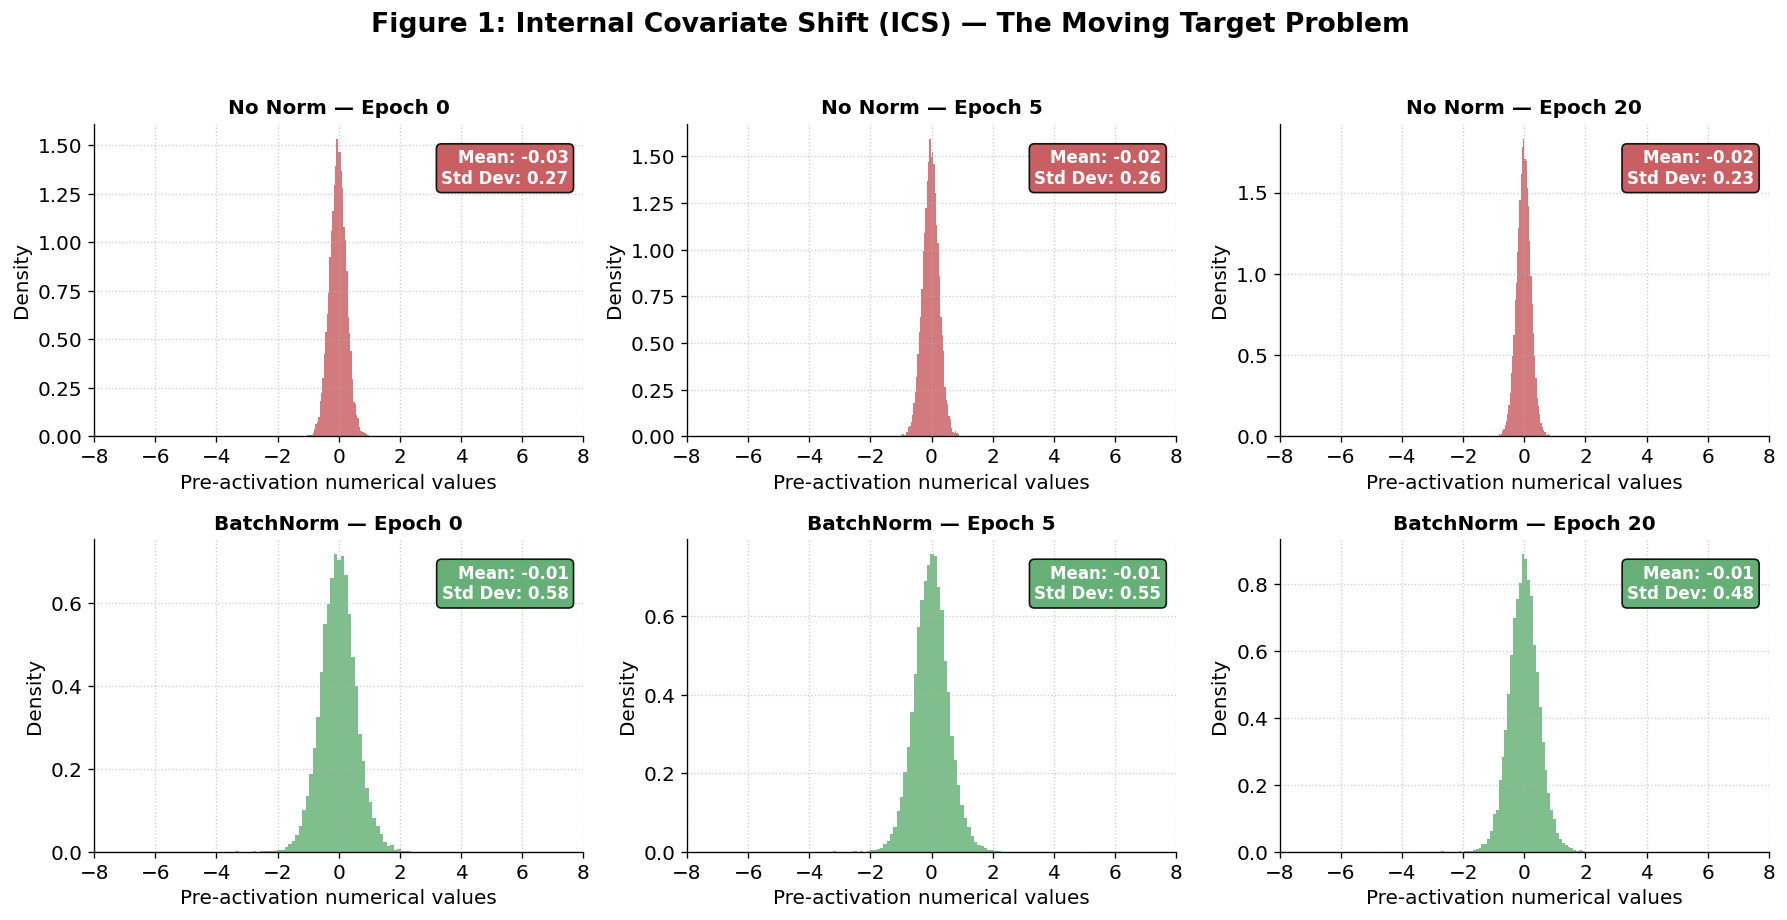

In [3]:
# Figure 1: Internal Covariate Shift — Distribution Shifts Without Normalization
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(2)
np.random.seed(2)

# Simulate pre-activation distributions at layer 2 across training steps
class NoNormNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(20, 64)
        self.l2 = nn.Linear(64, 64)
    def forward(self, x):
        return self.l2(torch.relu(self.l1(x)))

class BNNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(20, 64)
        self.bn = nn.BatchNorm1d(64)
        self.l2 = nn.Linear(64, 64)
    def forward(self, x):
        return self.l2(self.bn(torch.relu(self.l1(x))))

net_no = NoNormNet()
net_bn = BNNet()
x_fixed = torch.randn(256, 20)
# A dummy target for the network to try to learn
y_target = torch.randn(256, 64) * 2

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))

snapshots = [0, 5, 20]
opts = [torch.optim.SGD(net_no.parameters(), lr=0.08),
        torch.optim.SGD(net_bn.parameters(), lr=0.08)]
criterion = nn.MSELoss()

for ax_col, step in enumerate(snapshots):
    # Train for 'step' number of epochs
    for opt, net in zip(opts, [net_no, net_bn]):
        for _ in range(step):
            opt.zero_grad()
            out = net(x_fixed)
            loss = criterion(out, y_target)
            loss.backward()
            opt.step()

    # Collect layer-2 pre-activation distributions manually
    with torch.no_grad():
        acts_no = net_no.l2(torch.relu(net_no.l1(x_fixed))).numpy().flatten()
        acts_bn = net_bn.l2(net_bn.bn(torch.relu(net_bn.l1(x_fixed)))).numpy().flatten()

    for ax_row, (acts, title, col) in enumerate([
        (acts_no, f'No Norm — Epoch {step}', '#C44E52'),
        (acts_bn, f'BatchNorm — Epoch {step}', '#55A868'),
    ]):
        ax = axes[ax_row][ax_col]
        ax.hist(acts, bins=50, color=col, alpha=0.75, density=True)
        ax.set_xlim(-8, 8)
        
        # Add titles and labels
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Pre-activation numerical values')
        ax.set_ylabel('Density')
        
        # Fixed multi-line format string with \n
        stat_text = f"Mean: {acts.mean():.2f}\nStd Dev: {acts.std():.2f}"
        ax.text(0.97, 0.92, stat_text,
                transform=ax.transAxes, ha='right', va='top', fontsize=10, color='white', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=col, edgecolor='black', alpha=0.9))
        ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Figure 1: Internal Covariate Shift (ICS) — The Moving Target Problem',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 2. Batch Normalization — Math, Forward Pass & Learning Parameters

### Intuition: Grading on a Curve

Imagine a teacher giving an exam to two different classes. Class A gets an impossibly hard test (average score: 30). Class B gets an easy test (average score: 90). 

If the teacher wants to evaluate how well a student did *relative* to their peers, the raw scores are useless. Instead, the teacher "grades on a curve." They reset the average score of both classes to exactly `0`, and adjust the spread of the scores to be exactly `1`. Now, a score of `+1.5` means the student did great in *their* specific class, regardless of whether the exam was hard or easy.

But what if the school requires final grades to be strictly between 50 and 100? The teacher takes those "curved" scores and applies a custom multiplier and bonus points to fit the school's required format.

**Batch Normalization (BatchNorm)** does exactly this to the data flowing through your neural network. It "curves" the data so no batch is wildly extreme, and then lets the network apply a custom multiplier ($\gamma$) and shift ($\beta$) to get the numbers exactly where they belong before passing them to the activation function.

---

### The 4-Step Forward Pass

When a mini-batch of data passes through a layer, BatchNorm analyzes each feature and performs 4 mathematical steps:

**Step 1: Batch Mean (The Average)**
$$\mu_{\mathcal{B}} = \frac{1}{B}\sum_{i=1}^{B} z_i$$
*Plain English:* Add up all the numbers for this feature in the current batch and find the average.

**Step 2: Batch Variance (The Spread)**
$$\sigma^2_{\mathcal{B}} = \frac{1}{B}\sum_{i=1}^{B}(z_i - \mu_{\mathcal{B}})^2$$
*Plain English:* Calculate how spread out the numbers are from the average.

**Step 3: Normalize (Grade on a Curve)**
$$\hat{z}_i = \frac{z_i - \mu_{\mathcal{B}}}{\sqrt{\sigma^2_{\mathcal{B}} + \epsilon}}$$
*Plain English:* Subtract the mean so the center is exactly `0`, and divide by the standard deviation so the spread is exactly `1`. (The tiny $\epsilon$ is just added so we never accidentally divide by zero).

**Step 4: Scale & Shift (Learnable Knobs)**
$$y_i = \gamma \hat{z}_i + \beta$$
*Plain English:* Multiply the normalized data by a learned weight ($\gamma$) and add a learned bias ($\beta$).

---

### Why do we need $\gamma$ and $\beta$?

If Step 3 perfectly normalizes our data, why do we immediately change it in Step 4?

**Let's look at the raw math to see exactly why this happens.**

Suppose a hidden layer outputs these 5 raw numbers:
`Raw = [40, 45, 50, 55, 60]` *(Mean = 50, StdDev = 7.07)*

**Step 3 (Normalization)** subtracts the mean and divides by 7.07, mathematically squishing our massive numbers into this tiny array:
`Normalized = [-1.41,  -0.71,  0.0,  0.71,  1.41]`

When you enforce a variance of `1`, you mathematically guarantee that most of your numbers will be trapped tightly between `-1` and `1`. 

**The "Straight Line" Problem:** Let's pass those tiny normalized numbers into a **Tanh** activation function.
*   `Tanh(-0.1)` = **`-0.10`**
*   `Tanh(0.0)`  = **`0.00`**
*   `Tanh(0.1)`  = **`0.10`**

Look closely at the math: For numbers near zero, `Tanh(x)` is mathematically identical to `y = x`. 
If `y = x`, the activation function is acting like a completely straight, flat line! If the network only uses this straight line, it mathematically devolves into a basic Linear Regression. It literally loses the "Deep" in Deep Learning because it's no longer bending space (non-linearity).

**How $\gamma$ (Gamma) saves the day:**
To get the deep learning curve back, the numbers need to hit the extreme, twisty edges of the `Tanh` function (like near `-3` and `+3`). 

The network learns that it needs a curve, so it updates $\gamma$ (Scale) to equal `3.0`.
It takes our trapped data `[-1.41, ..., 1.41]` and multiplies it by `3.0`:
`Scaled = [-4.2, ..., 4.2]`

When we pass *these* numbers into Tanh, we get `Tanh(4.2) = 0.999`. The network is no longer operating on a straight line; it is using the extreme, squished asymptotes of the curve, meaning it has successfully regained its non-linear power!

---

### Where does BatchNorm go?
```text
Linear / Conv Layer  ➡️  BatchNorm  ➡️  Activation Function (e.g., ReLU)
```
*Note: Based on the original 2015 paper, it is applied after the matrix multiplication, but before the non-linearity.*

---

### Master Interview Q&A

> **Q: What is the exact mathematical purpose of the learnable $\gamma$ and $\beta$ parameters in Batch Normalization?**
> 
> **A:** If we rigidly force all data to have a mean of `0` and a variance of `1`, the numbers will cluster tightly around zero. For activation functions like Sigmoid or Tanh, the region exactly around zero is essentially a straight, flat line. If the network only ever uses this linear region, it loses its ability to learn complex, non-linear patterns. $\gamma$ (Scale) and $\beta$ (Shift) solve this by allowing the network to dynamically stretch and slide the standardized numbers outward, ensuring they hit the non-linear, curved portions of the activation function. If the network mathematically decides that normalization is hurting a specific feature, it can literally learn to perfectly undo it by setting $\gamma = \sigma$ and $\beta = \mu$.

> **Q: How does a Batch Normalization layer mathematically behave differently during Training vs. Inference?**
> 
> **A:** During training, BatchNorm calculates the `mean` and `variance` live from the mini-batch currently passing through it. But during inference, you might only pass in one single image, meaning there is no "batch" to calculate a mean from. To solve this, during training, the network secretly saves a running average of all the batch statistics it sees. During inference (when `.eval()` is called), it completely stops calculating live math and locks in that saved historical average, making the prediction 100% deterministic.

> **Q: How does Batch Normalization act as a form of Implicit Regularization (similar to Dropout)?**
> 
> **A:** Because every mini-batch is drawn randomly, the `mean` and `variance` calculated by the layer will always be slightly different (noisy). Because BatchNorm uses these noisy statistics to scale the data, the exact same image will be represented by slightly different numbers every time it passes through the network, depending entirely on the other images randomly batched with it. This continuous mathematical "jitter" prevents neurons from perfectly memorizing specific inputs, acting as a soft, implicit regularizer.


══ BatchNorm Forward — Manual ══════════════════════════
  Input z:    [ 2.1 -0.5  3.2  0.8 -1.2  4.5  1.1  0.3]
  μ_B:        1.2875
  σ²_B:       3.1586
  ẑ (norm):   [ 0.4572 -1.0058  1.0761 -0.2743 -1.3996  1.8076 -0.1055 -0.5556]
  y = γẑ + β: [ 0.9858 -1.2087  1.9142 -0.1115 -1.7995  3.0114  0.1417 -0.5335]
  γ=1.5, β=0.3

  PyTorch BN output: [ 0.9858 -1.2087  1.9142 -0.1115 -1.7995  3.0114  0.1417 -0.5335]
  Max difference (manual vs PyTorch): 1.90e-07



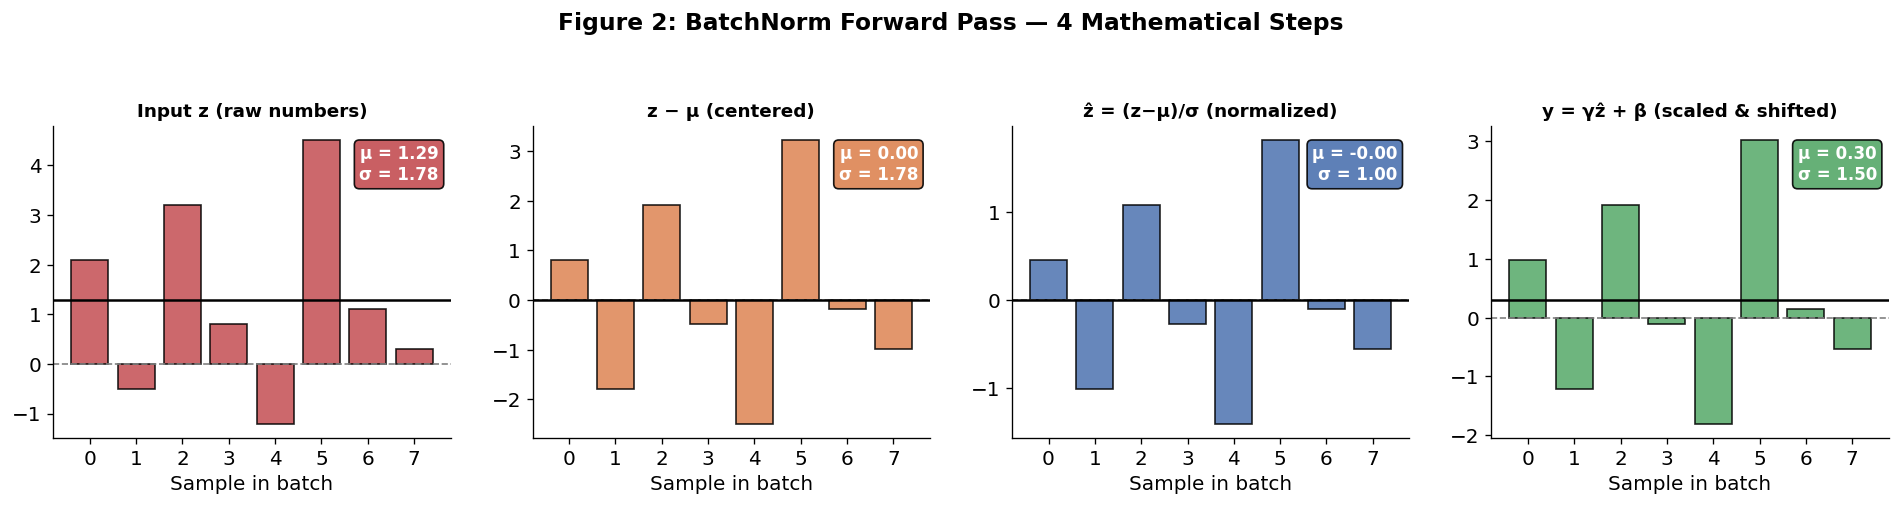

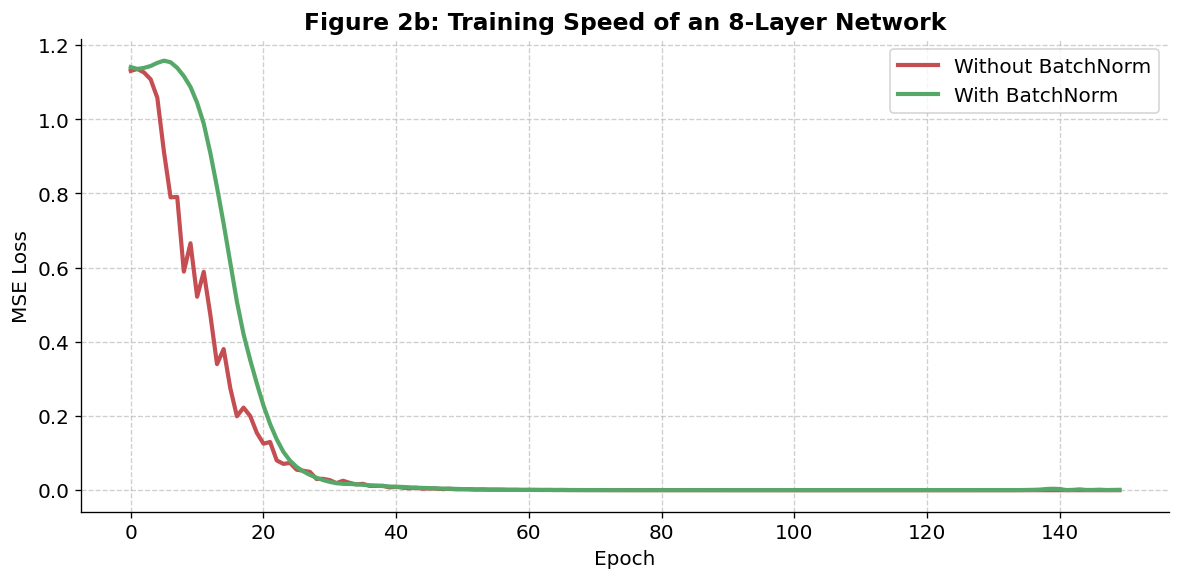

In [7]:
# Figure 2: BatchNorm Forward Pass — 4 Steps + Training Speed Impact
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)

# ── Manual BatchNorm forward (numpy) ──────────────────────────────
B, C = 8, 1     # batch of 8, single feature for clarity
z = np.array([2.1, -0.5, 3.2, 0.8, -1.2, 4.5, 1.1, 0.3])  # raw pre-activations

eps = 1e-5
mu  = z.mean()
var = z.var()
z_hat = (z - mu) / np.sqrt(var + eps)
gamma, beta = 1.5, 0.3   # learnable scale and shift
y = gamma * z_hat + beta

print("══ BatchNorm Forward — Manual ══════════════════════════")
print(f"  Input z:    {z}")
print(f"  μ_B:        {mu:.4f}")
print(f"  σ²_B:       {var:.4f}")
print(f"  ẑ (norm):   {z_hat.round(4)}")
print(f"  y = γẑ + β: {y.round(4)}")
print(f"  γ={gamma}, β={beta}\n")

# ── Verify with PyTorch ───────────────────────────────────────────
z_t = torch.tensor(z, dtype=torch.float32).unsqueeze(1)   # (8,1)
bn  = nn.BatchNorm1d(1, eps=eps, momentum=0.1)
bn.weight.data.fill_(gamma)
bn.bias.data.fill_(beta)
bn.train()
y_t = bn(z_t).detach().numpy().flatten()
print(f"  PyTorch BN output: {y_t.round(4)}")
print(f"  Max difference (manual vs PyTorch): {np.abs(y - y_t).max():.2e}\n")

# ── Part 1: Step-by-Step Visualization ─────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

stages = [
    (z,     'Input z (raw numbers)',             '#C44E52'),
    (z-mu,  'z − μ (centered)',                  '#DD8452'),
    (z_hat, 'ẑ = (z−μ)/σ (normalized)',          '#4C72B0'),
    (y,     'y = γẑ + β (scaled & shifted)',     '#55A868'),
]
for ax, (vals, title, col) in zip(axes, stages):
    ax.bar(range(len(vals)), vals, color=col, alpha=0.85, edgecolor='black')
    ax.axhline(0, color='grey', lw=1, ls='--')
    ax.axhline(vals.mean(), color='black', lw=1.5, ls='-', label=f'μ={vals.mean():.2f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Sample in batch')
    ax.set_xticks(range(len(vals)))
    
    # Fixed Syntax Error: Used \n instead of a raw newline in the string
    stat_text = f"μ = {vals.mean():.2f}\nσ = {vals.std():.2f}"
    ax.text(0.97, 0.94, stat_text,
            transform=ax.transAxes, ha='right', va='top', fontsize=10, color='white', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=col, edgecolor='black', alpha=0.9))

plt.suptitle('Figure 2: BatchNorm Forward Pass — 4 Mathematical Steps', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# ── Part 2: Impact on Training Speed (Fixed Loop Bug) ──────────────
torch.manual_seed(0)

def make_deep(use_bn):
    layers = []
    for i in range(8):
        layers.append(nn.Linear(64, 64))
        if use_bn: 
            layers.append(nn.BatchNorm1d(64))
        layers.append(nn.ReLU())
    layers.append(nn.Linear(64, 1))
    return nn.Sequential(*layers)

X = torch.randn(256, 64)
y_target = torch.randn(256, 1)

fig2, ax2 = plt.subplots(figsize=(10, 5))

# Fixed logical bug: Plotted the history INSIDE the loop so both lines appear
for use_bn, label, col in [(False, 'Without BatchNorm', '#C44E52'), (True, 'With BatchNorm', '#55A868')]:
    net = make_deep(use_bn)
    opt = torch.optim.Adam(net.parameters(), lr=1e-2)
    hist = []
    
    for _ in range(150):
        net.train()
        opt.zero_grad()
        loss = nn.MSELoss()(net(X), y_target)
        if not torch.isnan(loss): 
            loss.backward()
            opt.step()
            
        net.eval()
        with torch.no_grad(): 
            eval_loss = nn.MSELoss()(net(X), y_target).item()
            hist.append(eval_loss)

    ax2.plot(hist, color=col, lw=2.5, label=label)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('MSE Loss', fontsize=12)
ax2.set_title('Figure 2b: Training Speed of an 8-Layer Network', fontsize=14, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=12)
plt.tight_layout()
plt.show()


## Batch Normalization Computation (2D Visualization)

If 3D plotting is too messy, here is a highly effective, clean **2D visualization** using `matplotlib`'s grid tools. 

This diagram explicitly breaks a batch of 3 images into their separate feature channels (e.g., Red, Green, Blue) and visually highlights exactly which blocks of numbers are averaged together to compute the Mean and Variance for one channel.

You can paste this straight into your Jupyter Notebook:

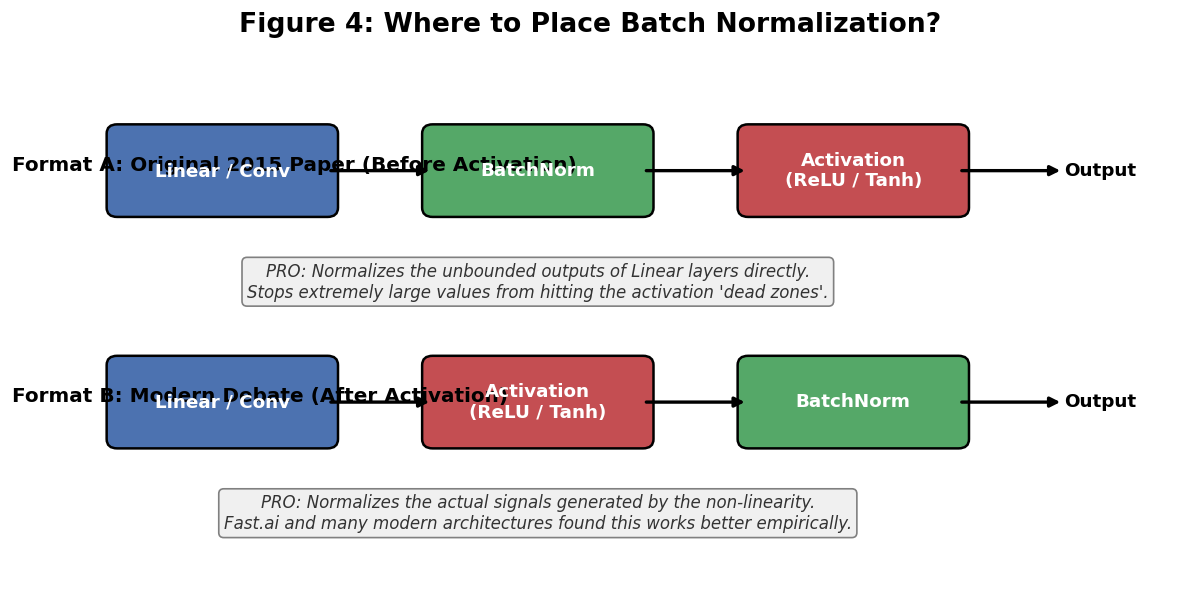

In [15]:
# Figure 4: BatchNorm Architectural Placement Diagram
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 5))

def draw_block(ax, x, y, width, height, text, color, text_color='white'):
    box = patches.FancyBboxPatch((x, y), width, height, 
                                 boxstyle="round,pad=0.1", 
                                 ec="black", fc=color, lw=1.5)
    ax.add_patch(box)
    ax.text(x + width/2, y + height/2, text, 
            ha='center', va='center', color=text_color, 
            fontsize=11, fontweight='bold')

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(facecolor='black', edgecolor='black', 
                                arrowstyle='-|>', lw=2))

# --- Flow 1: Original Paper (Before Activation) ---
y_top = 3
ax.text(-1, y_top + 0.4, "Format A: Original 2015 Paper (Before Activation)", 
        fontsize=12, fontweight='bold')

draw_block(ax, 0, y_top, 2, 0.8, "Linear / Conv", '#4C72B0')
draw_arrow(ax, 2, y_top + 0.4, 3, y_top + 0.4)

draw_block(ax, 3, y_top, 2, 0.8, "BatchNorm", '#55A868')
draw_arrow(ax, 5, y_top + 0.4, 6, y_top + 0.4)

draw_block(ax, 6, y_top, 2, 0.8, "Activation\n(ReLU / Tanh)", '#C44E52')
draw_arrow(ax, 8, y_top + 0.4, 9, y_top + 0.4)

ax.text(9, y_top + 0.4, "Output", verticalalignment='center', fontsize=11, fontweight='bold')


# --- Flow 2: Modern Debate (After Activation) ---
y_bottom = 0.5
ax.text(-1, y_bottom + 0.4, "Format B: Modern Debate (After Activation)", 
        fontsize=12, fontweight='bold')

draw_block(ax, 0, y_bottom, 2, 0.8, "Linear / Conv", '#4C72B0')
draw_arrow(ax, 2, y_bottom + 0.4, 3, y_bottom + 0.4)

draw_block(ax, 3, y_bottom, 2, 0.8, "Activation\n(ReLU / Tanh)", '#C44E52')
draw_arrow(ax, 5, y_bottom + 0.4, 6, y_bottom + 0.4)

draw_block(ax, 6, y_bottom, 2, 0.8, "BatchNorm", '#55A868')
draw_arrow(ax, 8, y_bottom + 0.4, 9, y_bottom + 0.4)

ax.text(9, y_bottom + 0.4, "Output", verticalalignment='center', fontsize=11, fontweight='bold')

# --- Add Intuition Text Boxes ---
ax.text(4, 2.2, 
        "PRO: Normalizes the unbounded outputs of Linear layers directly.\nStops extremely large values from hitting the activation 'dead zones'.", 
        fontsize=10, style='italic', color='#333333', ha='center', va='center',
        bbox=dict(facecolor='#f0f0f0', edgecolor='gray', boxstyle='round,pad=0.3'))

ax.text(4, -0.3, 
        "PRO: Normalizes the actual signals generated by the non-linearity.\nFast.ai and many modern architectures found this works better empirically.", 
        fontsize=10, style='italic', color='#333333', ha='center', va='center',
        bbox=dict(facecolor='#f0f0f0', edgecolor='gray', boxstyle='round,pad=0.3'))

# Clean up axes
ax.set_xlim(-1, 10)
ax.set_ylim(-1, 4.5)
ax.axis('off')

plt.suptitle("Figure 4: Where to Place Batch Normalization?", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## Batch Normalization: Calculate by Hand & Architectural Fit

### The Golden Rule of Architecture: Computer Vision (CNNs)
**Batch Normalization (BatchNorm) is the undisputed king of Computer Vision.**
*   **Examples:** ResNet, VGG, YOLO.
*   **Why?** In Computer Vision, before you feed images to a GPU, you aggressively crop and resize every single image to be the exact same dimensions (e.g., $224 \times 224$ pixels). Because every input is perfectly uniform, there is no "padding," and there are no "variable lengths." You can confidently load a perfectly uniform Batch of 32 images, and BatchNorm easily calculates beautiful, stable statistics across them.

---

### Why BatchNorm Fails for Text (NLP & Transformers)
If you try to use BatchNorm on text, the math catastrophically breaks down for two reasons:
1.  **The Padding Problem:** Sentences are all different lengths. To make a short 5-word sentence fit into a massive GPU matrix, we pad it with 500 fake trailing `[PAD] (0)` tokens. BatchNorm blindly grabs everything in the batch dimension and averages it. It accidentally averages thousands of meaningless `0` padding tokens into the mathematical mean, completely destroying the statistics of the real words.
2.  **Auto-Regressive Generation:** When you ask an LLM (like ChatGPT) a question, it replies by generating exactly *one single word at a time*. This means during inference, your **Batch Size is strictly 1**. You mathematically cannot calculate the Variance (spread) of a single number. The BatchNorm equation instantly divides by zero (or epsilon) and explodes.

---

### Calculate by Hand: How BatchNorm works mathematically

Let's pretend we have a batch of **3 images**. Each image is incredibly simple, containing only **2 features** (e.g., Feature 1: "Redness", Feature 2: "Roundness").

**Our Raw Batch of Data:**
*   **Image 1:** `[10, 2]`
*   **Image 2:** `[20, 4]`
*   **Image 3:** `[30, 6]`

**Step 1: Isolate ONE feature across the entire Batch.**
BatchNorm *does not mix features*. It exclusively looks at Feature 1 across all 3 images.
*   Feature 1 values: `[10, 20, 30]`

**Step 2: Calculate the Batch Mean ($\mu$) and Variance ($\sigma^2$)**
*   Mean of `[10, 20, 30]` = **`20`**
*   Variance = Calculate how far each number is from the mean, square it, and average them:
    *   $(10-20)^2 = 100$
    *   $(20-20)^2 = 0$
    *   $(30-20)^2 = 100$
    *   Average of `[100, 0, 100]` = **`66.67`**
*   Standard Deviation ($\sigma$) = $\sqrt{66.67}$ ≈ **`8.16`**

**Step 3: Normalize that specific feature**
We subtract the Mean (`20`) and divide by the StdDev (`8.16`) for every Image!
*   **Image 1 (F1):** $(10 - 20) / 8.16 =$ **`-1.22`**
*   **Image 2 (F1):** $(20 - 20) / 8.16 =$ **`0.00`**
*   **Image 3 (F1):** $(30 - 20) / 8.16 =$ **`+1.22`**

BatchNorm then instantly repeats this exact same mathematical process for Feature 2 (`[2, 4, 6]`), completely isolated from the Feature 1 math!


## 3. Batch Normalization at Test Time — Running Statistics

### The Test-Time Problem
At training time, BatchNorm uses the **current mini-batch** statistics ($\mu_{\mathcal{B}}, \sigma^2_{\mathcal{B}}$).

At test time:
- We often predict **one sample at a time** → no "batch" to compute statistics over
- Batch of 1 has $\mu = z$ and $\sigma = 0$ → normalised output = 0 always
- Even with batch > 1: test batches are different from training batches

**Solution: Maintain running estimates** of mean and variance during training.

---

### Running Statistics (Exponential Moving Average)

After each training batch, update running estimates:
$$\mu_{\text{run}} \leftarrow (1 - m)\mu_{\text{run}} + m\cdot\mu_{\mathcal{B}}$$
$$\sigma^2_{\text{run}} \leftarrow (1-m)\sigma^2_{\text{run}} + m\cdot\sigma^2_{\mathcal{B}}$$

- $m$ = momentum (PyTorch default: 0.1) — how much to update from current batch
- After training, $\mu_{\text{run}}$ and $\sigma^2_{\text{run}}$ approximate the **population statistics**

### Test-time Normalisation
$$\hat{z}_i = \frac{z_i - \mu_{\text{run}}}{\sqrt{\sigma^2_{\text{run}} + \epsilon}}$$
$$y_i = \gamma\hat{z}_i + \beta$$

Same $\gamma, \beta$ learned during training — no change.
Only the statistics source changes: **batch stats → running stats**.

### Why `model.train()` / `model.eval()` Switches These
```python
model.train()   # BN uses batch mean/var; updates running stats
model.eval()    # BN uses running mean/var; does NOT update
```

This is the second reason (besides Dropout) to always call `model.eval()` before inference.

### The Batch Size Constraint
BatchNorm requires a sufficiently large batch to get stable statistics.
- Batch size < 8: statistics too noisy → training unstable
- Typical minimum: 16–32 per GPU
- **This is why BatchNorm fails with very small batches** → use LayerNorm or GroupNorm instead

#### Interview Questions: BatchNorm Test Time
> **Q: Why does BatchNorm behave differently at train vs test time?**
> A: Training: uses current mini-batch statistics (noisy but up-to-date). Test: uses running statistics accumulated over training (stable population estimates). `model.eval()` switches between these modes.

> **Q: What happens if you forget model.eval() with a BatchNorm model?**
> A: BatchNorm continues using mini-batch statistics from whatever you pass in as a "batch". For single samples, this is degenerate. For small test batches, the statistics are noisy and inconsistent with training, causing unpredictable outputs.

> **Q: What is the momentum parameter in BatchNorm?**
> A: Controls how fast running statistics update. Higher momentum → faster update (more weight to current batch). PyTorch default is 0.1 (10% from new batch each step). Not to be confused with optimizer momentum.


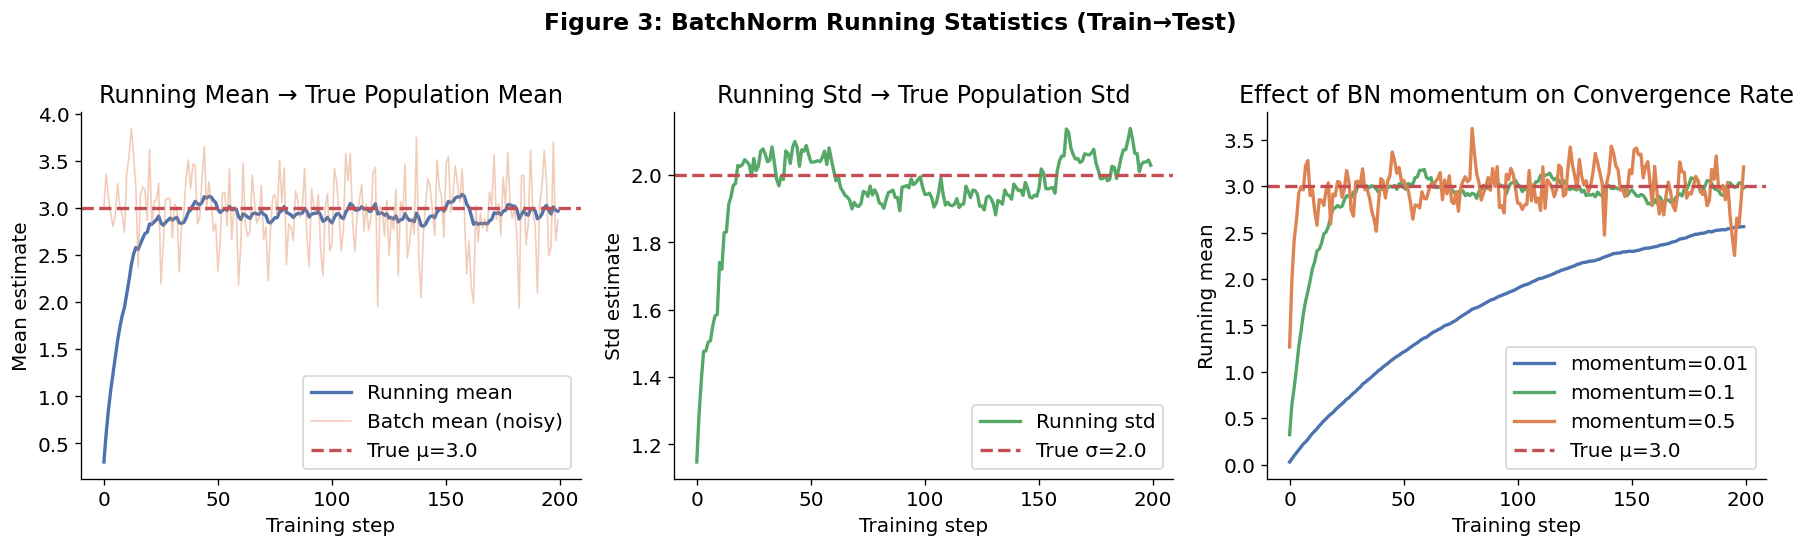

In [9]:
# Figure 3: Running Statistics — convergence to population stats
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt

torch.manual_seed(0)

# True population: N(3.0, 2.0²)
true_mu, true_std = 3.0, 2.0
n_steps = 200
batch_size = 32

bn = nn.BatchNorm1d(1, momentum=0.1)
bn.train()

running_means, running_vars = [], []
batch_means_hist = []

for _ in range(n_steps):
    x_batch = torch.randn(batch_size, 1) * true_std + true_mu
    _ = bn(x_batch)   # triggers running stat update
    running_means.append(bn.running_mean.item())
    running_vars.append(bn.running_var.item())
    batch_means_hist.append(x_batch.mean().item())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
steps = range(n_steps)

# ── Plot 1: Running mean convergence ──
axes[0].plot(steps, running_means,    color='#4C72B0', lw=2, label='Running mean')
axes[0].plot(steps, batch_means_hist, color='#DD8452', lw=1, alpha=0.4, label='Batch mean (noisy)')
axes[0].axhline(true_mu, color='#C44E52', ls='--', lw=2, label=f'True μ={true_mu}')
axes[0].set_xlabel('Training step'); axes[0].set_ylabel('Mean estimate')
axes[0].set_title('Running Mean → True Population Mean'); axes[0].legend()

# ── Plot 2: Running var convergence ──
running_stds = np.sqrt(np.array(running_vars))
axes[1].plot(steps, running_stds,    color='#55A868', lw=2, label='Running std')
axes[1].axhline(true_std, color='#C44E52', ls='--', lw=2, label=f'True σ={true_std}')
axes[1].set_xlabel('Training step'); axes[1].set_ylabel('Std estimate')
axes[1].set_title('Running Std → True Population Std'); axes[1].legend()

# ── Plot 3: Effect of momentum on convergence rate ──
for mom, col in [(0.01,'#4C72B0'),(0.1,'#55A868'),(0.5,'#DD8452')]:
    bn_m = nn.BatchNorm1d(1, momentum=mom); bn_m.train()
    rm = []
    for _ in range(n_steps):
        xb = torch.randn(32,1)*true_std + true_mu
        bn_m(xb)
        rm.append(bn_m.running_mean.item())
    axes[2].plot(steps, rm, color=col, lw=2, label=f'momentum={mom}')
axes[2].axhline(true_mu, color='#C44E52', ls='--', lw=2, label=f'True μ={true_mu}')
axes[2].set_xlabel('Training step'); axes[2].set_ylabel('Running mean')
axes[2].set_title('Effect of BN momentum on Convergence Rate'); axes[2].legend()

plt.suptitle('Figure 3: BatchNorm Running Statistics (Train→Test)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 4. Layer Normalization — The NLP & Transformer Standard

### Intuition: The Hospital Patient Analogy

Imagine a hospital trying to determine if a patient is healthy. 
*   **Batch Normalization** measures a patient's heart rate and compares it to the average heart rate of every other person currently sitting in the waiting room. 
    *   *The Problem:* If a patient walks in alone (Batch Size = 1), you can't calculate an average. Or, if half the room is filled with marathon runners and the other half is filled with elderly patients (Variable Sequence Lengths), the "average" is meaningless and corrupted.
*   **Layer Normalization** ignores the waiting room entirely. Instead, it looks *only* at the current patient. It calculates the average of all of *that one patient's* vitals (Heart Rate, Blood Pressure, Temperature, etc.) and normalizes them against each other. 

By normalizing across the **features** of a single sample (instead of across the batch), Layer Normalization mathematically guarantees that the network can reliably process data even if the batch size is exactly 1, which is a hard requirement for modern Large Language Models.

---

### The Mathematical Forward Pass

In LayerNorm, the mean and variance are restricted to the hidden dimension $H$ (the number of features/vitals) for a single specific token or sample $i$.

**Step 1 & 2: Sample-Specific Mean and Variance**
$$\mu_i = \frac{1}{H}\sum_{j=1}^{H}z_{ij}, \qquad \sigma_i^2 = \frac{1}{H}\sum_{j=1}^{H}(z_{ij}-\mu_i)^2$$
*Plain English:* For one specific word/token, add up all its feature numbers (embeddings) and find the average and spread. We do not look at any other words or sentences in the batch.

**Step 3 & 4: Normalize, Scale, and Shift**
$$\hat{z}_{i} = \frac{z_i - \mu_i}{\sqrt{\sigma_i^2 + \epsilon}} \cdot \gamma + \beta$$
*Plain English:* Subtract the mean, divide by the standard deviation, and then use the learnable volume dials $\gamma$ and $\beta$ to stretch and bend the data back into the interesting parts of the activation function.

---

### Why Batch Normalization fails for Transformers (NLP)
1.  **Variable Lengths (The Padding Problem):** In NLP, every sentence is a different length. We "pad" short sentences with hundreds of `[PAD] (0)` tokens so the matrices fit in the GPU. If BatchNorm calculates an average across the batch, it accidentally includes thousands of meaningless `0` padding tokens, completely corrupting the statistical math.
2.  **Auto-Regressive Generation:** When you ask ChatGPT a question, it generates the response one single word at a time. This means the inference Batch Size is strictly `1`. BatchNorm mathematically explodes if you ask it to calculate the variance of a single number.

### Why LayerNorm succeeds
LayerNorm is perfectly isolated to a single sequence. It doesn't care if there are millions of padding tokens in the batch, because it evaluates each token independently. It trains perfectly on massive batches, and infers perfectly on a batch of 1. It also doesn't need to maintain a "Running Average" like BatchNorm, meaning it behaves 100% identically during both Train and Eval modes.

---

### Master Interview Q&A

> **Q: Why do Transformers fundamentally require Layer Normalization instead of Batch Normalization?**
> 
> **A:** Transformers process text, which comes in variable-length sequences requiring heavy padding. BatchNorm calculates its statistics across the entire batch dimension, meaning it would incorporate millions of meaningless padding tokens into its mean and variance, mathematically corrupting the data. Furthermore, LLMs generate text "auto-regressively" (one token at a time at inference), meaning the inference batch size is effectively 1. BatchNorm mathematically breaks down at a batch size of 1 because the variance of a single item is zero. LayerNorm fixes this by normalizing across the feature dimension of a single token, rendering it immune to both padding and batch-size constraints.

> **Q: A major architectural shift occurred between the original "Attention is All You Need" paper and modern LLMs like LLaMA regarding LayerNorm. What was it, and why did it happen?**
> 
> **A:** The original 2017 Transformer paper mathematically placed LayerNorm *after* the residual addition (`Post-LN`: `x + Sublayer(x) -> LayerNorm`). However, researchers quickly realized this caused massive gradient instability early in training, requiring long, delicate Learning Rate Warmup phases just to prevent the model from exploding. Modern architectures (like GPT and LLaMA) use `Pre-LN` (`x + Sublayer(LayerNorm(x))`). By applying LayerNorm inside the residual branch *before* the computation, the identity highway remains perfectly uninterrupted. This smooths the loss landscape exponentially better, completely removing the need for learning rate warmups.


## Layer Normalization: Calculate by Hand & Architectural Fit

### The Golden Rule of Architecture: NLP & Transformers
**Layer Normalization (LayerNorm) is the undisputed king of Modern Deep Learning.**
*   **Examples:** GPT-4, LLaMA, BERT, Vision Transformers (ViT).
*   **Why?** Language is chaotic. One sentence is 3 words, the next is 500 words. Because Transformers process sequential data that constantly changes in length, LayerNorm evaluates the internal features of a *single token* completely independently. This renders it entirely immune to the chaos of sequence lengths, padding tokens, and batch size scaling.

---

### The Paradox: Why does BatchNorm work for 1 Image, but fail for 1 Text Token?

*Wait a minute... During inference, if I use an iPhone to classify a picture of a dog, I am only passing **1 image** into the CNN (Batch Size = 1). Why does BatchNorm work perfectly fine there, but explode for auto-regressive text?*

This is a brilliant, senior-level question. 

**How BatchNorm survives 1 Image:**
During *training*, BatchNorm secretly saves a running historical average of all the batch statistics it sees. When you deploy the model on your iPhone (inference), you call `model.eval()`. This locks the BatchNorm layer. It completely stops doing live math, and simply applies that locked historical average to the single dog image. It works perfectly because every image it trained on was cropped to the exact same $224 \times 224$ uniform shape, so the historical average is mathematically sound.

**Why that trick fails for Text (Auto-Regression):**
In NLP, sentences are variable lengths. To fit them in training batches, we pad them with thousands of `[PAD] (0)` tokens. During training, BatchNorm accidentally includes all these meaningless zeroes into its running historical average.
When you try to use `model.eval()` to generate text auto-regressively (predicting one token at a time), BatchNorm tries to apply that saved historical average. But the average is completely corrupted by padding garbage! The prediction fails. 

**LayerNorm** never uses historical averages. It calculates live statistics using the internal embedding dimensions of the *current token itself*. It works perfectly on a batch size of 1, without needing to save any historical memory.

---

### Calculate by Hand: Auto-Regressive Text Generation

Let's pretend we are generating text with an LLM. We just fed it the prompt `"Hello"`, and it is now trying to generate the next token. 

The LLM represents the word `"Hello"` as a single Token vector containing **4 Embedding Dimensions** (in reality, GPT-4 uses 12,288 dimensions).

**Our Raw Token (Batch Size = 1):**
*   **Token 1 ("Hello"):** `[8, 4, 12, 16]`

Because we are doing auto-regression, we are generating one token, so we only have 1 item. BatchNorm would divide by zero and crash right here.

**Step 1: Isolate the Single Token and look across its internal Embedding Dimensions.**
LayerNorm exclusively isolates Token 1, and grabs all 4 of its embedding values.
*   Token 1 values: `[8, 4, 12, 16]`

**Step 2: Calculate the Mean ($\mu$) and Variance ($\sigma^2$) inside this single Token**
*   Mean of `[8, 4, 12, 16]` = **`10`**
*   Variance = Calculate how far each dimension is from the mean:
    *   $(8 - 10)^2 = 4$
    *   $(4 - 10)^2 = 36$
    *   $(12 - 10)^2 = 4$
    *   $(16 - 10)^2 = 36$
    *   Average of `[4, 36, 4, 36]` = **`20`**
*   Standard Deviation ($\sigma$) = $\sqrt{20}$ ≈ **`4.47`**

**Step 3: Normalize the internal dimensions of Token 1**
We subtract the Mean (`10`) and divide by the StdDev (`4.47`) for every single dimension strictly *inside* Token 1!
*   **Dim 1:** $(8 - 10) / 4.47 =$ **`-0.45`**
*   **Dim 2:** $(4 - 10) / 4.47 =$ **`-1.34`**
*   **Dim 3:** $(12 - 10) / 4.47 =$ **`+0.45`**
*   **Dim 4:** $(16 - 10) / 4.47 =$ **`+1.34`**

LayerNorm is finished. The token `"Hello"` is perfectly normalized internally, and it had zero reliance on batch statistics, historical averages, or padding tokens. It is now passed to the next layer to predict the next word!


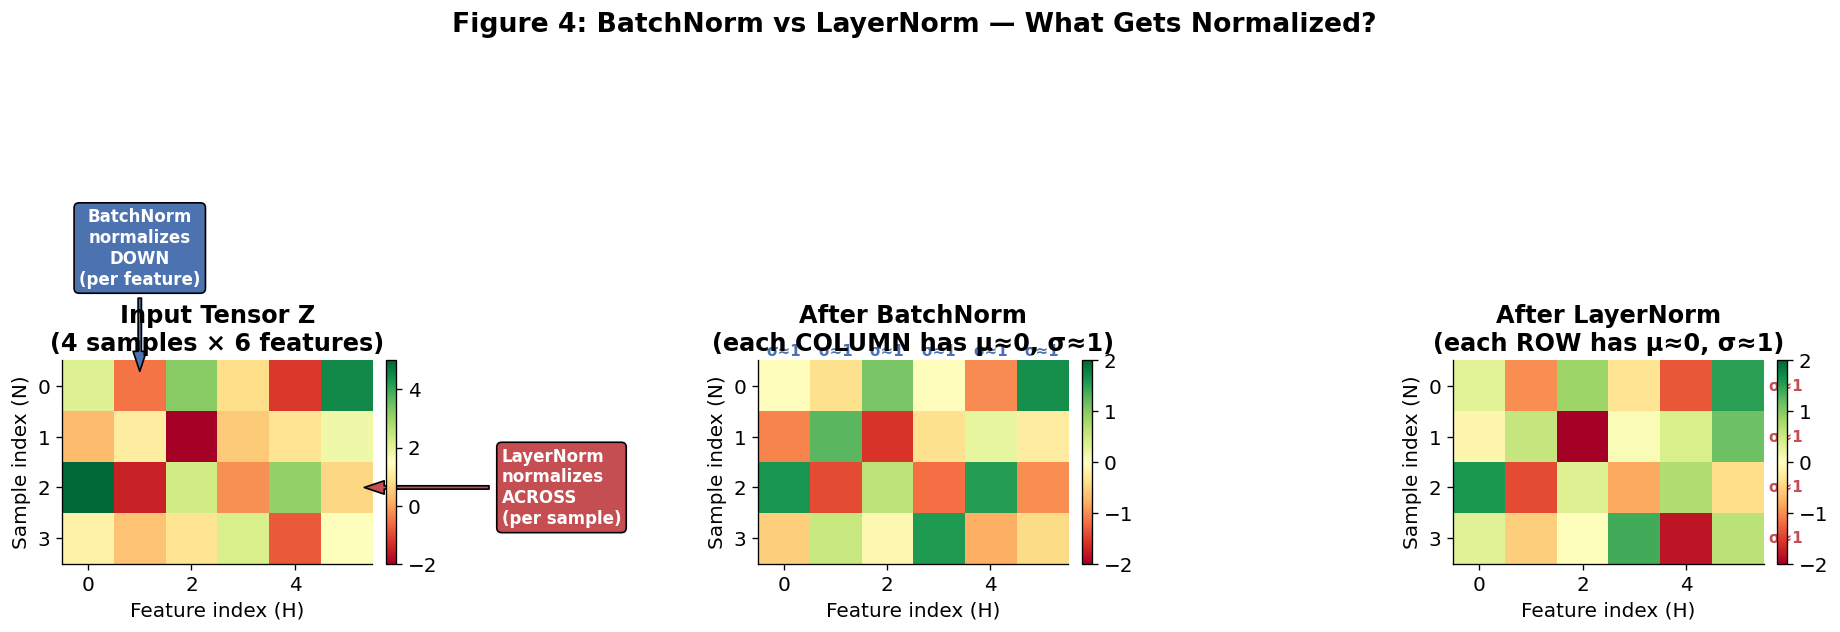

══ After BatchNorm (Normalizing COLUMN-WISE) ══
  μ per feature (column): [ 0. -0. -0.  0.  0.  0.]
  σ per feature (column): [1. 1. 1. 1. 1. 1.]

══ After LayerNorm (Normalizing ROW-WISE) ══
  μ per sample (row): [ 0. -0. -0.  0.]
  σ per sample (row): [1. 1. 1. 1.]


In [17]:
# Figure 4: BatchNorm vs LayerNorm — What Gets Normalised
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

# (N=4 samples/images/tokens, H=6 features/embeddings)
z = torch.tensor([
    [2.1, -0.5,  3.2,  0.8, -1.2,  4.5],
    [0.3,  1.1, -2.0,  0.5,  0.9,  1.8],
    [5.0, -1.5,  2.3, -0.2,  3.1,  0.7],
    [1.2,  0.4,  0.9,  2.2, -0.8,  1.5],
], dtype=torch.float32)   # shape (4, 6)

# BatchNorm: normalise over N for each feature (vertically)
bn = nn.BatchNorm1d(6, eps=1e-5, affine=False)
z_bn = bn(z).detach().numpy()

# LayerNorm: normalise over H for each sample (horizontally)
ln = nn.LayerNorm(6, eps=1e-5, elementwise_affine=False)
z_ln = ln(z).detach().numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Heatmap — show what gets normalised ──
im0 = axes[0].imshow(z.numpy(), cmap='RdYlGn', aspect='auto', vmin=-2, vmax=5)
axes[0].set_title('Input Tensor Z\n(4 samples × 6 features)', fontweight='bold')
axes[0].set_xlabel('Feature index (H)')
axes[0].set_ylabel('Sample index (N)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Fixed String formatting using '\n'
axes[0].annotate('BatchNorm\nnormalizes\nDOWN\n(per feature)', 
                 xy=(1, -0.2), xytext=(1, -2), 
                 fontsize=10, fontweight='bold', color='white', ha='center',
                 bbox=dict(boxstyle='round', facecolor='#4C72B0', edgecolor='black'),
                 arrowprops=dict(facecolor='#4C72B0', edgecolor='black', shrink=0.05, width=2, headwidth=8))

axes[0].annotate('LayerNorm\nnormalizes\nACROSS\n(per sample)', 
                 xy=(5.2, 2), xytext=(8, 2), 
                 fontsize=10, fontweight='bold', color='white', va='center',
                 bbox=dict(boxstyle='round', facecolor='#C44E52', edgecolor='black'),
                 arrowprops=dict(facecolor='#C44E52', edgecolor='black', shrink=0.05, width=2, headwidth=8))


# ── Plot 2: After BatchNorm ──
im1 = axes[1].imshow(z_bn, cmap='RdYlGn', aspect='auto', vmin=-2, vmax=2)
axes[1].set_title('After BatchNorm\n(each COLUMN has μ≈0, σ≈1)', fontweight='bold')
axes[1].set_xlabel('Feature index (H)')
axes[1].set_ylabel('Sample index (N)')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

for j in range(6):
    col_vals = z_bn[:, j]
    axes[1].text(j, -0.6, f'σ≈{col_vals.std():.0f}', ha='center', fontsize=9, fontweight='bold', color='#4C72B0')


# ── Plot 3: After LayerNorm ──
im2 = axes[2].imshow(z_ln, cmap='RdYlGn', aspect='auto', vmin=-2, vmax=2)
axes[2].set_title('After LayerNorm\n(each ROW has μ≈0, σ≈1)', fontweight='bold')
axes[2].set_xlabel('Feature index (H)')
axes[2].set_ylabel('Sample index (N)')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for i in range(4):
    row_vals = z_ln[i, :]
    axes[2].text(5.6, i, f'σ≈{row_vals.std():.0f}', va='center', fontsize=9, fontweight='bold', color='#C44E52')


plt.suptitle('Figure 4: BatchNorm vs LayerNorm — What Gets Normalized?',
             fontsize=16, fontweight='bold', y=1.05)

# Ignore plotting clipping for arrows that go outside the box
axes[0].set_clip_on(False)
plt.tight_layout()
plt.show()

# ── Stats verification ──
print("══ After BatchNorm (Normalizing COLUMN-WISE) ══")
print("  μ per feature (column):", z_bn.mean(axis=0).round(2))
print("  σ per feature (column):", z_bn.std(axis=0).round(2))
print()

print("══ After LayerNorm (Normalizing ROW-WISE) ══")
print("  μ per sample (row):", z_ln.mean(axis=1).round(2))
print("  σ per sample (row):", z_ln.std(axis=1).round(2))


## 5. Instance Normalization & Group Normalization

While BatchNorm is the king of standard Computer Vision, and LayerNorm is the king of NLP, there are two major Edge Cases in deep learning where both of them fail. That is where Instance and Group Normalization step in.

---

### Instance Normalization (The "Instagram Filter")

**Where it's used:** Style Transfer and Image Generation (GANs, Diffusion Models).

**The Intuition:**
Imagine you have a photo of a modern city, and you want an AI to repaint it in the style of Vincent van Gogh's *Starry Night*. 
In Computer Vision, a specific image's "Style" (its contrast, brightness, and color palette) is strongly encoded in the Mean and Variance of its feature channels. 
If we want to apply a *new* style, we first need to completely erase the *old* style.

**How it works mathematically:**
For a batch of images `(N, C, H, W)`:
*   **BatchNorm** averages a channel across *all* images in the batch.
*   **InstanceNorm** averages a channel for **a single specific image** `(H, W)`.

By normalizing the spatial pixels `(H, W)` of *one channel* for *one image* independently, InstanceNorm strips away that specific image's original contrast and brightness. The network then learns new $\gamma$ and $\beta$ parameters to artificially inject the *new* Van Gogh style back into that blank canvas.

---

### Group Normalization (The "High-Resolution Compromise")

**Where it's used:** Medical Imaging, Satellite Imagery, High-Resolution Object Detection (Mask R-CNN).

**The Problem:**
If you are processing massive 4K resolution images on a GPU, you might physically run out of VRAM. You might be forced to set your **Batch Size to exactly 1 or 2**. 
*   We know **BatchNorm** mathematically breaks down and becomes incredibly noisy if the batch size is less than 8. 
*   We know **LayerNorm** works on a Batch Size of 1, but it averages *all* feature channels together. In a CNN, different channels detect completely different things (Channel 1 detects "Cat Ears", Channel 100 detects "Blue Sky"). Averaging them together destroys their unique spatial meaning.

**The Solution:**
Group Normalization (Wu & He, 2018) is the perfect compromise. 
Instead of averaging *all* channels together (LayerNorm), or relying on an impossible batch size (BatchNorm), it divides the channels into smaller **Groups** (e.g., 32 groups). 

It calculates the Mean and Variance across the spatial pixels `(H, W)` within that specific *group* of channels, for a single image. 

**The Mathematical Spectrum:**
Let $G$ be the number of groups, and $C$ be the total number of channels.
*   If $G = 1$: You grouped all channels together. This is mathematically identical to **LayerNorm**.
*   If $G = C$: Every single channel is in its own isolated group. This is mathematically identical to **InstanceNorm**.
*   If $G = 32$: This is standard **GroupNorm**. It safely balances statistics without needing a large batch size!

---

### Calculate by Hand: Instance vs. Group Normalization

Let's pretend we have a single very small image (Batch Size = 1).
It has **4 feature channels**, and each channel only has **2 spatial pixels** ($H \times W$).

**Raw Data for Image 1:**
*   **Channel 1 (Detects Edges):**   `[10, 20]`
*   **Channel 2 (Detects Texture):** `[30, 40]`
*   **Channel 3 (Detects Color):**   `[5, 15]`
*   **Channel 4 (Detects Corners):** `[25, 35]`

#### 1. How InstanceNorm Calculates it (Groups = 4)
InstanceNorm puts every single channel into its own isolated bubble. Let's do **Channel 1**.
1.  **Isolate:** It grabs *only* Channel 1's pixels: `[10, 20]`.
2.  **Mean & Var:** Mean = **15**. Variance = Calculate spread from 15: $(10-15)^2=25$, $(20-15)^2=25$. Average of `[25, 25]` = 25. StdDev = **5**.
3.  **Normalize:** 
    *   Pixel 1: $(10 - 15) / 5 =$ **`-1.0`**
    *   Pixel 2: $(20 - 15) / 5 =$ **`+1.0`**

It repeats this completely independently for Channel 2, 3, and 4. The statistics of Channel 1 had absolutely zero impact on the statistics of Channel 2.

#### 2. How GroupNorm Calculates it (Groups = 2)
GroupNorm groups similar channels together so it can average *more* pixels at once, creating drastically stabler math. Let's say we split our 4 channels into **2 Groups** (2 channels per group).

**Group 1** contains Channel 1 and Channel 2.
1.  **Isolate Group:** It grabs *all* pixels from both channels simultaneously: `[10, 20, 30, 40]`.
2.  **Mean & Var:** Mean = **25**. Variance = Avg of `[225, 25, 25, 225]` = 125. StdDev ≈ **11.18**.
3.  **Normalize Channel 1 (Using Group Stats):**
    *   Pixel 1: $(10 - 25) / 11.18 =$ **`-1.34`**
    *   Pixel 2: $(20 - 25) / 11.18 =$ **`-0.45`**
4.  **Normalize Channel 2 (Using Group Stats):**
    *   Pixel 1: $(30 - 25) / 11.18 =$ **`+0.45`**
    *   Pixel 2: $(40 - 25) / 11.18 =$ **`+1.34`**

Look at what happened! In GroupNorm, the high numbers in Channel 2 actively skewed the Mean (dragging it up to 25). This heavily impacted how Channel 1 was normalized (making Channel 1's pixels entirely negative). By grouping features, GroupNorm stabilizes small batches by letting channels support each other statistically.

---

### Master Interview Q&A

> **Q: Why was Group Normalization created, exactly what constraint does it solve?**
> 
> **A:** Group Normalization was created specifically to solve the "Small Batch Size" problem in Computer Vision. For tasks like Medical Imaging or Object Detection, the image resolutions are so massive that GPUs can only fit a Batch Size of 1 or 2. BatchNorm mathematically breaks down and introduces extreme noise at those miniature batch sizes. GroupNorm fixes this by abandoning the Batch dimension entirely. Instead, it normalizes across spatial dimensions within smaller "groups" of feature channels. This allows it to maintain perfectly stable statistics completely independent of batch size, while outperforming LayerNorm which destructively averages all visual features together.


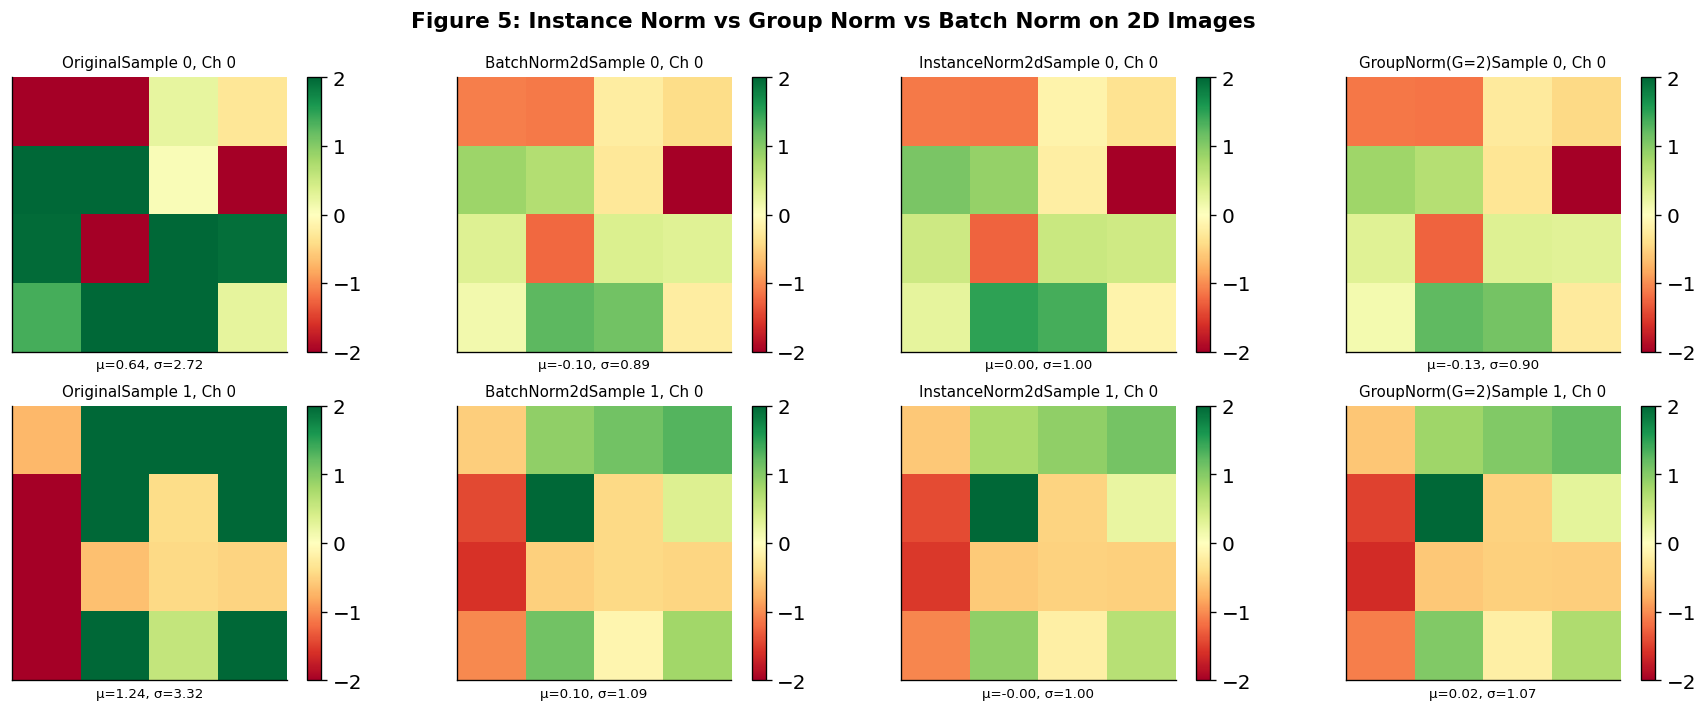

BatchNorm   — mean per channel (across both samples):
  Ch 0: μ=-0.0000, σ=1.0160
  Ch 1: μ=-0.0000, σ=1.0160
  Ch 2: μ=-0.0000, σ=1.0160
  Ch 3: μ=0.0000, σ=1.0160

InstanceNorm — mean per sample per channel:
  Sample 0, Ch 0: μ=0.0000, σ=1.0328
  Sample 0, Ch 1: μ=0.0000, σ=1.0328
  Sample 0, Ch 2: μ=-0.0000, σ=1.0328
  Sample 0, Ch 3: μ=-0.0000, σ=1.0328
  Sample 1, Ch 0: μ=-0.0000, σ=1.0328
  Sample 1, Ch 1: μ=0.0000, σ=1.0328
  Sample 1, Ch 2: μ=0.0000, σ=1.0328
  Sample 1, Ch 3: μ=0.0000, σ=1.0328


In [19]:
# Figure 5: InstanceNorm + GroupNorm — what they normalise
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt

torch.manual_seed(0)

# Image tensor: (N=2, C=4, H=4, W=4)
x = torch.randn(2, 4, 4, 4) * 3 + 1   # non-zero mean

inst_norm  = nn.InstanceNorm2d(4, affine=False)
group_norm = nn.GroupNorm(num_groups=2, num_channels=4, affine=False)
batch_norm = nn.BatchNorm2d(4, affine=False)

x_in  = inst_norm(x).detach()
x_gn  = group_norm(x).detach()
x_bn  = batch_norm(x).detach()

fig, axes = plt.subplots(2, 4, figsize=(15, 6))

titles = ['Original', 'BatchNorm2d', 'InstanceNorm2d', 'GroupNorm(G=2)']
tensors = [x, x_bn, x_in, x_gn]

for row in range(2):     # two samples
    for col, (title, t) in enumerate(zip(titles, tensors)):
        # Show first channel of each sample
        img = t[row, 0].numpy()
        im = axes[row][col].imshow(img, cmap='RdYlGn', vmin=-2, vmax=2)
        axes[row][col].set_title(f'{title}Sample {row}, Ch 0', fontsize=9)
        axes[row][col].set_xlabel(f'μ={img.mean():.2f}, σ={img.std():.2f}', fontsize=8)
        axes[row][col].set_xticks([]); axes[row][col].set_yticks([])
        plt.colorbar(im, ax=axes[row][col])

plt.suptitle('Figure 5: Instance Norm vs Group Norm vs Batch Norm on 2D Images',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print stats to confirm
print("BatchNorm   — mean per channel (across both samples):")
for c in range(4):
    print(f"  Ch {c}: μ={x_bn[:,c].mean():.4f}, σ={x_bn[:,c].std():.4f}")
print()
print("InstanceNorm — mean per sample per channel:")
for n in range(2):
    for c in range(4):
        print(f"  Sample {n}, Ch {c}: μ={x_in[n,c].mean():.4f}, σ={x_in[n,c].std():.4f}")


## 7. Comparison Table — Which Normalization, When?

### Normalisation Axes Summary

| Method | Normalises over | Shape input | Use case |
|--------|----------------|-------------|----------|
| **BatchNorm** | Batch (N) + spatial | (N, C, H, W) or (N, C) | CNNs, MLPs (batch≥16) |
| **LayerNorm** | Feature (C+H+W) | (N, C) or (N, L, C) | Transformers, RNNs |
| **InstanceNorm** | Spatial (H×W) per channel | (N, C, H, W) | Style transfer, GANs |
| **GroupNorm** | Group(C/G) + spatial | (N, C, H, W) | Object detection, small batches |

### Decision Guide
```
Are you training a Transformer or NLP model?
  → LayerNorm (always)

Are you training a CNN with batch size ≥ 16?
  → BatchNorm (best empirical performance)

Are you training a CNN with batch size < 8?
  → GroupNorm (G=32 is a good default)

Are you doing style transfer or image generation (GAN)?
  → InstanceNorm

Are you doing object detection (e.g., Mask R-CNN)?
  → GroupNorm (large images → small batch per GPU)
```

### Practical PyTorch API

```python
# BatchNorm
nn.BatchNorm1d(num_features)          # for (N, C) tensors
nn.BatchNorm2d(num_features)          # for (N, C, H, W) tensors

# LayerNorm
nn.LayerNorm(normalized_shape)        # e.g., [512] or [512, 768]

# InstanceNorm
nn.InstanceNorm2d(num_features)

# GroupNorm
nn.GroupNorm(num_groups=32, num_channels=C)
```

### Key Properties

| Property | BatchNorm | LayerNorm | InstanceNorm | GroupNorm |
|----------|-----------|-----------|--------------|-----------|
| Needs large batch? | ✅ Yes | ❌ No | ❌ No | ❌ No |
| Same at train/test? | ❌ No | ✅ Yes | ✅ Yes | ✅ Yes |
| Works at batch=1? | ❌ No | ✅ Yes | ✅ Yes | ✅ Yes |
| Learnable γ, β? | ✅ Yes | ✅ Yes | Optional | ✅ Yes |
| Sequence-friendly? | ❌ No | ✅ Yes | ❌ No | ❌ No |


## 8. Weight Initialization: The "Goldilocks" Problem

### Intuition: The "Telephone Game" Analogy
Imagine you are playing the childhood game of **Telephone**. You whisper a secret to one person, they whisper it to the next, and so on.
*   **Vanishing (Weights too small):** Each person whispers so quietly that by the 10th person, the message is total silence. Information is lost forever.
*   **Exploding (Weights too large):** Each person screams into the next person's ear. By the 10th person, the message is just painful white noise.
*   **Good Initialization:** Each person speaks at the exact same volume they heard. The "Signal Variance" remains constant from the first person to the last.

**Weight Initialization is the art of ensuring that "Signal Variance" stays alive across 100+ layers of math.**

---

### The Three Death Traps of Bad Initialization

#### 1. The Zero Initialization (The "Robot" Problem)
If you initialize all weights to `0` (or any constant), every single neuron in a layer will compute the exact same output. During backpropagation, they will all receive the **exact same gradient**. 
*   They are "trapped" in a mathematical symmetry. 
*   No matter how long you train, they will always stay identical. 
*   Your 1,000-neuron layer effectively collapses into **1 single neuron**. 

#### 2. Vanishing Gradients (The "Dead End")
If weights are too small (e.g., all near $0.001$), the outputs of each layer get smaller and smaller. When these tiny numbers pass through a Sigmoid or Tanh activation, they land in the **center** where the function is almost flat. 
*   Gradients are multiplied by these tiny numbers layer-by-layer.
*   By the time the gradient reaches Layer 1, it is effectively **zero**. The early layers never learn.

#### 3. Exploding Gradients (The "NaN" Disaster)
If weights are too large, activations grow exponentially with depth. 
*   Internal values quickly hit the limits of computer memory.
*   Floating point numbers overflow, and your loss suddenly becomes **`NaN`** (Not a Number). Training is dead.

---

### The Solutions: Xavier (Glorot) and He (Kaiming)

To keep the signal alive, we need the **Variance of the Output** to equal the **Variance of the Input**.

#### 🎯 Xavier Initialization (1990s - for Sigmoid/Tanh)
Used when the activation function is symmetric around zero.
$$W \sim \mathcal{N}\left(0, \frac{1}{\text{fan\_in}}\right) \quad \text{or} \quad \frac{2}{\text{fan\_in} + \text{fan\_out}}$$
*   **Logic:** It keeps the signal in the "active" slope of Sigmoid/Tanh, avoiding the flat saturation zones.

#### 🔥 He Initialization (2015 - for ReLU)
When we use **ReLU**, half of our neurons are "dead" (output 0) at any given time because ReLU kills negative numbers.
If we use Xavier on ReLU, the signal variance will cut in half every layer! To fix this, we multiply by **2**.
$$W \sim \mathcal{N}\left(0, \frac{2}{\text{fan\_in}}\right)$$
*   **Logic:** The "2" compensates for the fact that ReLU essentially shuts down 50% of the network's variance.

---

### Master Interview Q&A

> **Q: Why can't we just initialize weights with very small random numbers (e.g., Gaussian with $\sigma=0.01$)?**
> 
> **A:** While this breaks symmetry, it fails as the network gets deeper. For a 100-layer network, multiplying the signal by $0.01$ a hundred times leads to a value so small ($10^{-200}$) that it falls below the precision of 32-bit floats. The variance collapses, leading to **Vanishing Gradients**. Modern initializers like Xavier or He solve this by scaling the weights based on the number of input connections (fan-in), ensuring the signal variance remains stable regardless of depth.

> **Q: Why does He Initialization specifically use a factor of 2 in the numerator, unlike Xavier?**
> 
> **A:** This is a direct consequence of the **ReLU** activation function. Since ReLU maps all negative inputs to zero, it effectively "kills" half of the signal variance in every forward pass. If you used Xavier, the variance would shrink by 50% at every layer, eventually vanishing. The factor of $2$ in He Initialization mathematically compensates for this 50% loss, keeping the signal variance constant as it propagates through the network.

> **Q: What is "Symmetry Breaking" and why does it matter?**
> 
> **A:** Symmetry breaking is the requirement that neurons in the same layer start with different weights. If neurons are initialized identically (e.g., all zeros), they will compute the same output and receive identical gradient updates during backprop. They will remain identical forever, preventing the network from learning different features. Random initialization is the simplest way to "break" this symmetry and allow each neuron to specialize in a different pattern.


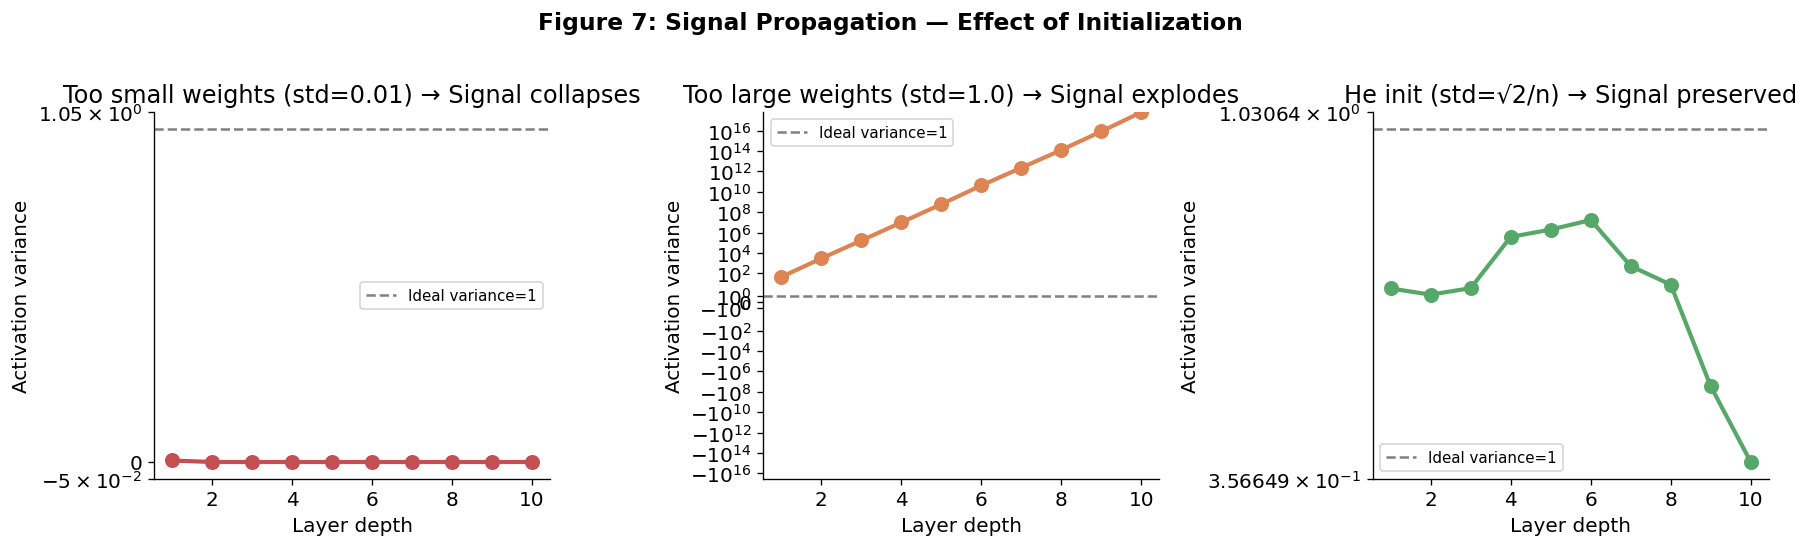

In [23]:
# Figure 7: Bad initialization — variance explosion and collapse
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt

torch.manual_seed(42)

n_layers = 10
n_units  = 128
N_samples = 512

x_in = torch.randn(N_samples, n_units)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, std_val, title, col in [
    (axes[0], 0.01,  'Too small weights (std=0.01) → Signal collapses', '#C44E52'),
    (axes[1], 1.0,   'Too large weights (std=1.0) → Signal explodes',   '#DD8452'),
    (axes[2], None,  'He init (std=√2/n) → Signal preserved',          '#55A868'),
]:
    var_per_layer = []
    x = x_in.clone()
    for l in range(n_layers):
        if std_val is not None:
            W = torch.randn(n_units, n_units) * std_val
        else:
            W = torch.randn(n_units, n_units) * np.sqrt(2.0 / n_units)
        x = torch.relu(x @ W.T)
        var_per_layer.append(x.var().item())

    ax.plot(range(1, n_layers+1), var_per_layer, 'o-', lw=2.5, color=col, ms=8)
    ax.set_xlabel('Layer depth'); ax.set_ylabel('Activation variance')
    ax.set_title(title)
    ax.axhline(1.0, color='grey', ls='--', lw=1.5, label='Ideal variance=1')
    ax.legend(fontsize=9)
    ax.set_yscale('symlog')

plt.suptitle('Figure 7: Signal Propagation — Effect of Initialization', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 9. Zero Initialization & The Symmetry Breaking Problem

### What Happens with Zero Init?

If all weights are initialised to 0:
$$W^{(l)} = 0 \implies z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)} = b^{(l)}$$

All neurons in layer $l$ compute **identical** pre-activations.
→ Identical activations → identical gradients → identical weight updates.

**After every training step, all neurons in a layer remain identical.**

No matter how long you train, the network behaves as if it had only 1 neuron per layer. This is the **symmetry breaking problem**.

### Constant Initialization is Equally Bad
Initialising all weights to the same non-zero constant has the same issue — all neurons remain symmetric.

### What to Init to Zero (and Why)
| Parameter | Init to Zero? | Reason |
|-----------|-------------|--------|
| **Weights $W$** | ❌ Never | Symmetry breaking |
| **Biases $b$** | ✅ Common | Biases don't have symmetry problem — OK to start at 0 |
| **BatchNorm γ** | ❌ (use 1) | Zero scale kills all output |
| **BatchNorm β** | ✅ OK | Zero shift is fine |
| **Output layer bias** | ✅ Or class-frequency log | Neutral starting prediction |

### The Random Init Solution
We need:
1. **Random** — break symmetry between neurons
2. **Small enough** — avoid saturation
3. **Large enough** — avoid signal collapse
4. **Scaled to layer width** — this is what Xavier and He solve precisely


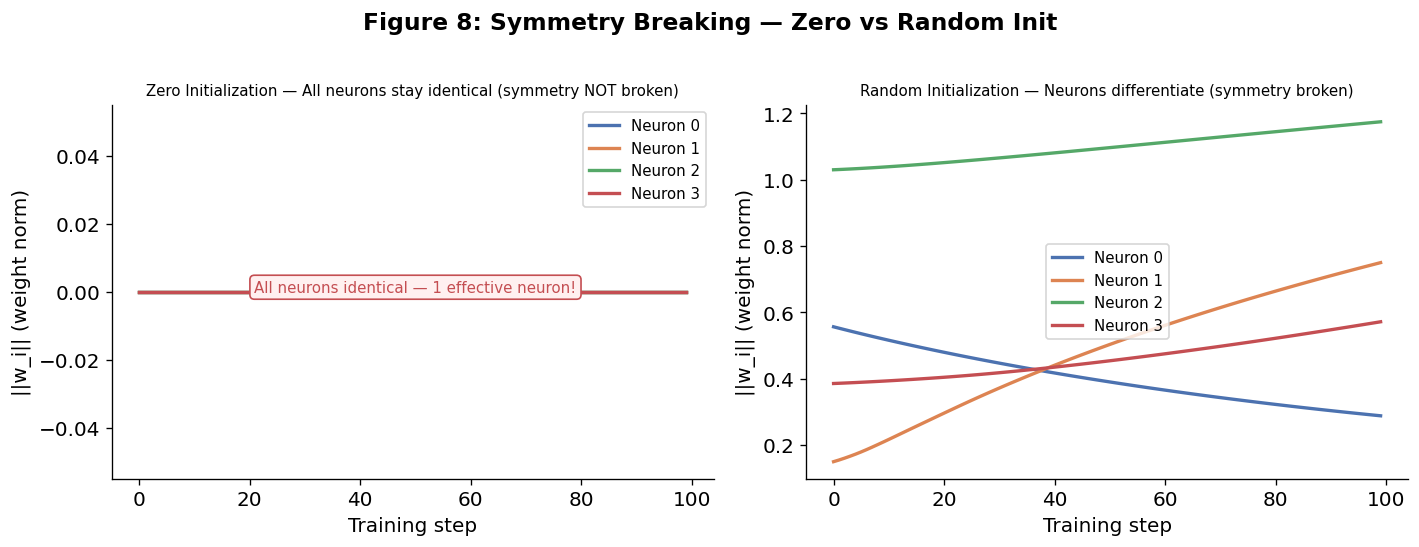

In [25]:
# Figure 8: Symmetry breaking — zero init vs random init
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt

torch.manual_seed(0)

# 2-layer net, 4 hidden neurons — watch them differentiate or not
class SmallNet(nn.Module):
    def __init__(self, zero_init):
        super().__init__()
        self.l1 = nn.Linear(2, 4, bias=False)
        self.l2 = nn.Linear(4, 1, bias=False)
        if zero_init:
            nn.init.zeros_(self.l1.weight)
            nn.init.zeros_(self.l2.weight)
        else:
            nn.init.normal_(self.l1.weight, std=0.5)
            nn.init.normal_(self.l2.weight, std=0.5)
    def forward(self, x):
        return self.l2(torch.relu(self.l1(x)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, zero_init, title in [
    (axes[0], True,  'Zero Initialization — All neurons stay identical (symmetry NOT broken)'),
    (axes[1], False, 'Random Initialization — Neurons differentiate (symmetry broken)'),
]:
    net = SmallNet(zero_init)
    opt = torch.optim.SGD(net.parameters(), lr=0.05)
    x   = torch.randn(32, 2)
    y   = (x[:,0] > 0).float().unsqueeze(1)

    weight_traces = [[] for _ in range(4)]  # track each hidden neuron's incoming weight norm

    for step in range(100):
        opt.zero_grad()
        nn.BCEWithLogitsLoss()(net(x), y).backward()
        opt.step()
        for i in range(4):
            weight_traces[i].append(net.l1.weight[i].norm().item())

    colors_w = ['#4C72B0','#DD8452','#55A868','#C44E52']
    for i, (trace, col) in enumerate(zip(weight_traces, colors_w)):
        ax.plot(trace, color=col, lw=2, label=f'Neuron {i}')
    ax.set_xlabel('Training step'); ax.set_ylabel('||w_i|| (weight norm)')
    ax.set_title(title, fontsize=9); ax.legend(fontsize=9)

    if zero_init:
        ax.text(50, max(weight_traces[0])*0.9,
                'All neurons identical — 1 effective neuron!',
                ha='center', fontsize=9, color='#C44E52',
                bbox=dict(boxstyle='round', facecolor='#fff0f0', edgecolor='#C44E52'))

plt.suptitle('Figure 8: Symmetry Breaking — Zero vs Random Init', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


#### Goal: Preserve Signal Variance Through Linear Layers

One of the key challenges in deep neural networks is **maintaining stable signal magnitude across layers**.  
If the variance of activations grows layer by layer, the network experiences **exploding activations**.  
If the variance shrinks, the network suffers from **vanishing signals**.

To prevent this, we want the **variance of the output of a layer to approximately equal the variance of its input**.

Consider a linear layer

$$
z = Wx
$$

where

- $x \in \mathbb{R}^{n_{\text{in}}}$ is the input vector  
- $W \in \mathbb{R}^{n_{\text{out}} \times n_{\text{in}}}$ is the weight matrix  

The $j$-th output neuron is

$$
z_j = \sum_{i=1}^{n_{\text{in}}} w_{ji} x_i
$$

To derive a good initialization, we first need to understand **how variance behaves under basic operations**.

---

#### 1. Variance Properties (The Mathematical Tools)

Variance measures the **spread or power of a signal**.  
When signals combine inside a neuron, their variances interact according to a few simple rules.

---

#### 1.1 Variance of a Sum (Independent Variables)

If two random variables $X$ and $Y$ are independent,

$$
\text{Var}(X + Y) = \text{Var}(X) + \text{Var}(Y)
$$

More generally, for independent variables

$$
\text{Var}\left(\sum_{i=1}^{n} X_i\right)
=
\sum_{i=1}^{n} \text{Var}(X_i)
$$

**Interpretation:**  
When independent signals are added together, their variances simply accumulate.

---

#### 1.2 Variance Under Scaling

If a random variable is multiplied by a constant $a$,

$$
\text{Var}(aX) = a^2 \text{Var}(X)
$$

This means scaling a signal by $a$ increases its variance by $a^2$.

Example:

- doubling a signal ($a=2$) increases variance by $4$.

---

#### 1.3 Variance of a Product (Zero Mean Case)

If two independent random variables have zero mean

$$
E[X] = 0, \qquad E[W] = 0
$$

then

$$
\text{Var}(WX) = \text{Var}(W)\text{Var}(X)
$$

This property is important because each term in a neural network neuron is a **product of a weight and an input**.

The zero-mean assumption is typically satisfied because weights are initialized with

$$
E[W] = 0
$$

---

#### 2. Variance Propagation Through a Linear Layer

Now we apply the above variance properties to a neuron.

Consider the output

$$
z_j = w_{j1}x_1 + w_{j2}x_2 + \dots + w_{j n_{\text{in}}}x_{n_{\text{in}}}
$$

We want to compute

$$
\text{Var}(z_j)
$$

---

#### Step 1: Apply Variance of a Sum

Assuming the terms are independent,

$$
\text{Var}(z_j)
=
\text{Var}(w_{j1}x_1)
+
\text{Var}(w_{j2}x_2)
+
\dots
+
\text{Var}(w_{j n_{\text{in}}}x_{n_{\text{in}}})
$$

---

#### Step 2: Apply Variance of a Product

Using

$$
\text{Var}(WX) = \text{Var}(W)\text{Var}(X)
$$

each term becomes

$$
\text{Var}(w_{ji}x_i)
=
\text{Var}(w_{ji}) \text{Var}(x_i)
$$

Thus

$$
\text{Var}(z_j)
=
\sum_{i=1}^{n_{\text{in}}}
\text{Var}(w_{ji})\text{Var}(x_i)
$$

---

#### Step 3: Assume Identical Distributions

During initialization we assume

- all weights have the same variance

$$
\text{Var}(w_{ji}) = \sigma_W^2
$$

- all inputs have the same variance

$$
\text{Var}(x_i) = \text{Var}(x)
$$

Then

$$
\text{Var}(z_j)
=
\sum_{i=1}^{n_{\text{in}}}
\sigma_W^2 \text{Var}(x)
$$

Since the terms are identical,

$$
\text{Var}(z_j)
=
n_{\text{in}} \sigma_W^2 \text{Var}(x)
$$

This is the key variance propagation result:

$$
\boxed{
\text{Var}(z_j) =
n_{\text{in}} \sigma_W^2 \text{Var}(x)
}
$$

---

#### 3. Forward Signal Variance Requirement

For stable signal propagation through deep networks, we want

$$
\text{Var}(z_j) \approx \text{Var}(x)
$$

Substitute the formula we derived:

$$
n_{\text{in}} \sigma_W^2 \text{Var}(x)
=
\text{Var}(x)
$$

Divide both sides by $\text{Var}(x)$:

$$
n_{\text{in}} \sigma_W^2 = 1
$$

Thus

$$
\sigma_W^2 = \frac{1}{n_{\text{in}}}
$$

This ensures **forward activations maintain constant variance**.

---

#### 4. Backward Gradient Variance Requirement

During backpropagation, gradients propagate through the transpose of the weight matrix.  
A similar derivation shows that to preserve gradient variance:

$$
\sigma_W^2 = \frac{1}{n_{\text{out}}}
$$

---

#### 5. Glorot (Xavier) Initialization

We now have two constraints:

Forward stability:

$$
\sigma_W^2 = \frac{1}{n_{\text{in}}}
$$

Backward stability:

$$
\sigma_W^2 = \frac{1}{n_{\text{out}}}
$$

Glorot & Bengio proposed balancing both by taking their average:

$$
\sigma_W^2 = \frac{2}{n_{\text{in}} + n_{\text{out}}}
$$

This is known as **Xavier (Glorot) initialization**.

---

#### Final Result

Weights are initialized with variance

$$
\boxed{
\sigma_W^2 = \frac{2}{n_{\text{in}} + n_{\text{out}}}
}
$$

Common implementations:

Uniform:

$$
W \sim U\left(-\sqrt{\frac{6}{n_{\text{in}} + n_{\text{out}}}},\,
\sqrt{\frac{6}{n_{\text{in}} + n_{\text{out}}}}\right)
$$

Normal:

$$
W \sim \mathcal{N}\left(0,\frac{2}{n_{\text{in}} + n_{\text{out}}}\right)
$$

---

#### Key Intuition

Each neuron sums many weighted inputs:

$$
z_j = \sum_i w_{ji}x_i
$$

Each input contributes variance.  
If we do nothing, the variance grows with the number of inputs:

$$
\text{Var}(z_j) \propto n_{\text{in}}
$$

Therefore we must scale weight variance by

$$
\frac{1}{n_{\text{in}}}
$$

so that **signal variance remains stable across layers**, enabling deep networks to train successfully.


### PyTorch
```python
nn.init.xavier_uniform_(layer.weight)     # uniform version
nn.init.xavier_normal_(layer.weight)      # normal version
```
PyTorch default for `nn.Linear` is **Kaiming (He) uniform**, NOT Xavier.

### When to Use Xavier
- Tanh or Sigmoid activation functions
- Linear output layers
- Embeddings

**Not ideal for ReLU** — ReLU kills half the neurons, so effective fan-in is $n_{\text{in}}/2$, requiring a factor of 2 correction → that's He initialization.

In [ ]:
# Figure 9: Xavier Init — variance preservation through tanh layers
import torch, numpy as np, matplotlib.pyplot as plt

torch.manual_seed(42)

n_layers = 15
n_units  = 256
N_samp   = 1024
x0 = torch.randn(N_samp, n_units)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Compare inits with tanh activation
strategies = [
    ('Normal std=0.01',  lambda ni, no: torch.randn(no,ni)*0.01,            '#C44E52'),
    ('Xavier uniform',   lambda ni, no: torch.nn.init.xavier_uniform_(torch.empty(no,ni)), '#4C72B0'),
    ('Xavier normal',    lambda ni, no: torch.nn.init.xavier_normal_(torch.empty(no,ni)),  '#55A868'),
]

for strat_name, init_fn, col in strategies:
    x = x0.clone()
    var_hist = []
    for _ in range(n_layers):
        W = init_fn(n_units, n_units)
        x = torch.tanh(x @ W.T)
        var_hist.append(x.var().item())
    axes[0].plot(range(1, n_layers+1), var_hist, 'o-', lw=2, color=col,
                 label=strat_name, ms=6)

axes[0].set_xlabel('Layer depth'); axes[0].set_ylabel('Activation variance (tanh)')
axes[0].set_title('Xavier Init — Variance Preservation (tanh)')
axes[0].legend(); axes[0].set_yscale('symlog')
axes[0].axhline(0.1, color='grey', ls=':', lw=1)

# ── Manual Xavier forward pass ──
ni, no = 512, 256
W_xavier = torch.empty(no, ni)
torch.nn.init.xavier_uniform_(W_xavier)

axes[1].hist(W_xavier.numpy().flatten(), bins=60, color='#4C72B0', alpha=0.8, density=True)
expected_bound = np.sqrt(6 / (ni + no))
axes[1].axvline( expected_bound, color='#C44E52', ls='--', lw=2, label=f'+√(6/(ni+no))={expected_bound:.4f}')
axes[1].axvline(-expected_bound, color='#C44E52', ls='--', lw=2, label=f'-√(6/(ni+no))')
axes[1].set_xlabel('Weight value'); axes[1].set_ylabel('Density')
axes[1].set_title(f'Xavier Uniform: ni={ni}, no={no}'); axes[1].legend(fontsize=9)

# ── Variance formula validation ──
ni_vals = [64, 128, 256, 512, 1024]
stds_expected, stds_actual = [], []
for ni in ni_vals:
    W = torch.empty(128, ni); torch.nn.init.xavier_normal_(W)
    stds_actual.append(W.std().item())
    stds_expected.append(np.sqrt(2 / (ni + 128)))

axes[2].plot(ni_vals, stds_expected, 'o-', color='#4C72B0', lw=2, ms=8, label='Expected σ=√(2/(ni+no))')
axes[2].plot(ni_vals, stds_actual,  's--', color='#55A868', lw=2, ms=8, label='Actual σ (PyTorch)')
axes[2].set_xlabel('n_in'); axes[2].set_ylabel('Weight std')
axes[2].set_title('Xavier Normal: Formula vs PyTorch'); axes[2].legend()

plt.suptitle('Figure 9: Xavier / Glorot Initialization', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


#### 11. He (Kaiming) Initialization — For ReLU Networks

#### Motivation

The goal of weight initialization is to keep the **variance of activations stable across layers**.  
If the variance shrinks layer by layer → signals vanish.  
If the variance grows → activations explode.

Earlier we derived **Xavier (Glorot) initialization** by requiring

$$
\text{Var}(z) \approx \text{Var}(x)
$$

for a linear layer

$$
z = Wx
$$

which resulted in

$$
\sigma_W^2 = \frac{2}{n_{\text{in}} + n_{\text{out}}}
$$

However, this derivation assumed **symmetric activation functions** such as:

- $\tanh$
- sigmoid

These activations preserve the **sign symmetry** of the signal.  
ReLU does **not**.

---

#### Why Xavier Fails for ReLU

ReLU is defined as

$$
a = \text{ReLU}(z) = \max(0, z)
$$

This operation **removes all negative values**.

If the pre-activation $z$ is approximately symmetric around zero (which is true at initialization),

then

- about **50% of values are negative**
- about **50% of values are positive**

After ReLU:

- negative values become **0**
- positive values remain unchanged

Thus roughly **half of the activations are zeroed out**.

---

#### Effect on Mean

Before ReLU:

$$
E[z] = 0
$$

After ReLU:

$$
E[a] = E[\max(0,z)] > 0
$$

The distribution becomes **positively biased**.

---

#### Effect on Variance

More importantly, ReLU changes the variance.

If

$$
z \sim \mathcal{N}(0,\sigma^2)
$$

then after ReLU the variance becomes approximately

$$
\text{Var}(\text{ReLU}(z)) \approx \frac{1}{2}\text{Var}(z)
$$

Intuition:

- half the values become **0**
- only half carry signal

So the signal power is roughly **cut in half**.

---

#### What Happens with Xavier + ReLU

From our earlier derivation

$$
\text{Var}(z) = n_{\text{in}} \sigma_W^2 \text{Var}(x)
$$

Xavier initialization ensures

$$
\text{Var}(z) = \text{Var}(x)
$$

But after ReLU

$$
\text{Var}(a) \approx \frac{1}{2}\text{Var}(z)
$$

Thus each layer reduces variance by about **0.5**.

After $L$ layers:

$$
\text{Var}(a_L) \approx \left(\frac{1}{2}\right)^L \text{Var}(x)
$$

For deep networks this causes

- **signal collapse**
- **vanishing gradients**
- very slow training

This is why **Xavier initialization performs poorly for deep ReLU networks**.

---

#### He Initialization: Correcting for ReLU

He et al. (2015) in the paper  
**"Delving Deep into Rectifiers"** analyzed this issue.

Since ReLU removes half the variance, we must **compensate during initialization**.

From the linear layer derivation:

$$
\text{Var}(z) = n_{\text{in}} \sigma_W^2 \text{Var}(x)
$$

After ReLU:

$$
\text{Var}(a) \approx \frac{1}{2}\text{Var}(z)
$$

Substitute the expression for $\text{Var}(z)$:

$$
\text{Var}(a)
=
\frac{1}{2}
\left(
n_{\text{in}} \sigma_W^2 \text{Var}(x)
\right)
$$

To preserve variance we want

$$
\text{Var}(a) = \text{Var}(x)
$$

Therefore

$$
\frac{1}{2} n_{\text{in}} \sigma_W^2 = 1
$$

Solving for $\sigma_W^2$:

$$
\sigma_W^2 = \frac{2}{n_{\text{in}}}
$$

This is **He initialization**.

---

#### He Initialization Formula

Weight variance:

$$
\boxed{
\sigma_W^2 = \frac{2}{n_{\text{in}}}
}
$$

---

#### Practical Distributions

#### He Normal Initialization

$$
W \sim \mathcal{N}\left(0,\frac{2}{n_{\text{in}}}\right)
$$

---

#### He Uniform Initialization

$$
W \sim \mathcal{U}\left(
-\sqrt{\frac{6}{n_{\text{in}}}},
+\sqrt{\frac{6}{n_{\text{in}}}}
\right)
$$

---

#### Intuition

A ReLU neuron **drops half the signal**.

To compensate, we **double the variance of the weights** during initialization.

Thus:

- Xavier assumes **all signals pass through**
- He initialization assumes **half the signals survive**

and scales the weights accordingly.

### PyTorch
```python
nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='relu')
nn.init.kaiming_uniform_(layer.weight, mode='fan_in', nonlinearity='relu')
```

- `mode='fan_in'`: normalises for forward pass (more common)
- `mode='fan_out'`: normalises for backward pass
- `nonlinearity`: adjusts gain for other activations (leaky_relu, tanh, etc.)

### He vs Xavier — When to Use Which

| Activation | Init |
|-----------|------|
| ReLU, Leaky ReLU, ELU, GELU | **He (Kaiming)** |
| Tanh, Sigmoid | **Xavier (Glorot)** |
| Linear (no activation) | **Xavier** |
| Embeddings | **Small uniform** or Xavier |

**PyTorch's `nn.Linear` default is He Uniform** — good for ReLU networks.

#### Interview Questions: Initialization
> **Q: What is the symmetry breaking problem and how is it solved?**
> A: If all weights initialised to the same value, all neurons in a layer compute identical outputs and receive identical gradients — they stay identical forever, reducing the layer to effectively 1 neuron. Solved by random initialisation from a zero-mean distribution.

> **Q: Derive why He initialisation uses a factor of 2 vs Xavier.**
> A: Xavier assumes symmetric activations: $\text{Var}(\text{ReLU}(z)) = \text{Var}(z)$. But ReLU zeroes negative inputs, halving the variance: $\text{Var}(\text{ReLU}(z)) \approx \frac{1}{2}\text{Var}(z)$. To compensate, we need weight variance $\sigma^2_W = 2/n_{\text{in}}$ instead of $1/n_{\text{in}}$ — the factor of 2 exactly corrects for the halving.

> **Q: Should you initialise biases to zero or random?**
> A: Biases to zero — they don't have the symmetry problem since each neuron has its own bias. Random bias init adds unnecessary noise without benefit.


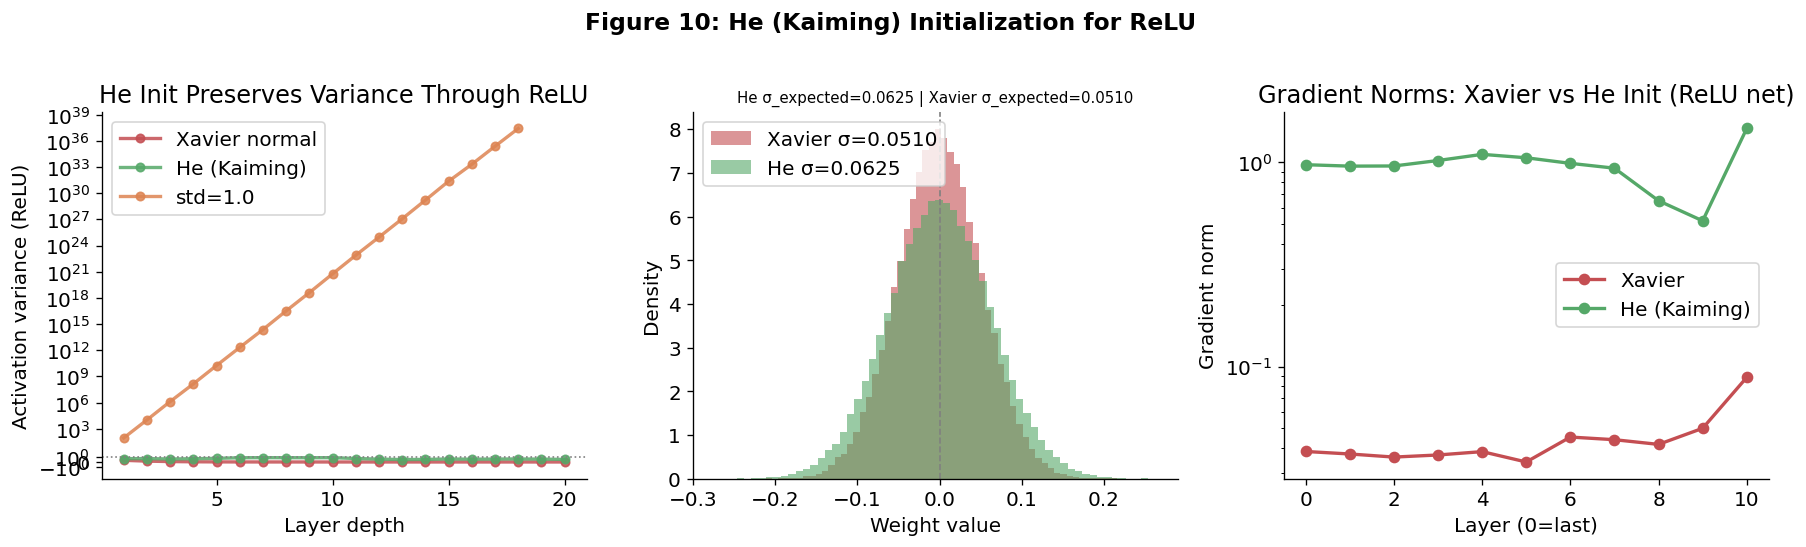

In [26]:
# Figure 10: He vs Xavier — with ReLU activation
import torch, numpy as np, matplotlib.pyplot as plt

torch.manual_seed(42)

n_layers = 20
n_units  = 256
N_samp   = 1024
x0 = torch.randn(N_samp, n_units)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Variance through ReLU layers ──
for name, init_fn, col in [
    ('Xavier normal', lambda n: torch.nn.init.xavier_normal_(torch.empty(n,n)),  '#C44E52'),
    ('He (Kaiming)',  lambda n: torch.nn.init.kaiming_normal_(torch.empty(n,n)), '#55A868'),
    ('std=1.0',       lambda n: torch.randn(n,n),                                '#DD8452'),
]:
    x = x0.clone(); var_hist = []
    for _ in range(n_layers):
        W = init_fn(n_units)
        x = torch.relu(x @ W.T)
        var_hist.append(x.var().item())
    axes[0].plot(range(1, n_layers+1), var_hist, 'o-', lw=2, color=col,
                 label=name, ms=5, alpha=0.85)

axes[0].set_xlabel('Layer depth'); axes[0].set_ylabel('Activation variance (ReLU)')
axes[0].set_title('He Init Preserves Variance Through ReLU')
axes[0].legend(); axes[0].set_yscale('symlog')
axes[0].axhline(1.0, color='grey', ls=':', lw=1)

# ── He weight distribution ──
ni = 512
W_he  = torch.empty(256, ni); torch.nn.init.kaiming_normal_(W_he, nonlinearity='relu')
W_xav = torch.empty(256, ni); torch.nn.init.xavier_normal_(W_xav)

axes[1].hist(W_xav.numpy().flatten(), bins=60, color='#C44E52', alpha=0.6,
             density=True, label=f'Xavier σ={W_xav.std():.4f}')
axes[1].hist(W_he.numpy().flatten(),  bins=60, color='#55A868', alpha=0.6,
             density=True, label=f'He σ={W_he.std():.4f}')
axes[1].axvline(0, color='grey', ls='--', lw=1)
axes[1].set_xlabel('Weight value'); axes[1].set_ylabel('Density')
axes[1].set_title(f'He vs Xavier Distribution (ni={ni})')
# Expected std
he_expected   = np.sqrt(2/ni)
xav_expected  = np.sqrt(2/(ni+256))
axes[1].set_title(f'He σ_expected={he_expected:.4f} | Xavier σ_expected={xav_expected:.4f}', fontsize=9)
axes[1].legend()

# ── Gradient norms at each layer ──
def make_deep_relu(init_name, n_layers=10, n=128):
    layers = []
    for _ in range(n_layers):
        l = torch.nn.Linear(n, n, bias=False)
        if init_name == 'xavier':
            torch.nn.init.xavier_normal_(l.weight)
        elif init_name == 'he':
            torch.nn.init.kaiming_normal_(l.weight, nonlinearity='relu')
        elif init_name == 'zero':
            torch.nn.init.constant_(l.weight, 0.01)
        layers += [l, torch.nn.ReLU()]
    return torch.nn.Sequential(*layers, torch.nn.Linear(n, 1, bias=False))

for init_nm, col, lbl in [('xavier','#C44E52','Xavier'),('he','#55A868','He (Kaiming)')]:
    net = make_deep_relu(init_nm)
    x_in = torch.randn(64, 128); y_in = torch.randn(64, 1)
    torch.nn.MSELoss()(net(x_in), y_in).backward()
    gnorms = []
    for m in net.modules():
        if isinstance(m, torch.nn.Linear) and m.weight.grad is not None:
            gnorms.append(m.weight.grad.norm().item())
    axes[2].plot(range(len(gnorms)), gnorms, 'o-', lw=2, color=col, ms=6, label=lbl)

axes[2].set_xlabel('Layer (0=last)'); axes[2].set_ylabel('Gradient norm')
axes[2].set_title('Gradient Norms: Xavier vs He Init (ReLU net)')
axes[2].legend(); axes[2].set_yscale('log')

plt.suptitle('Figure 10: He (Kaiming) Initialization for ReLU', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


#### 12. Orthogonal Initialization

#### Motivation

Standard random initialization (Gaussian or uniform) produces weight matrices whose rows are **not independent**.  
Two neurons may start with **highly correlated weights**, meaning they initially compute very similar features.

This leads to:

- redundant representations
- slower feature diversification during training

**Orthogonal initialization** addresses this by initializing the weight matrix so that its rows (or columns) are **orthogonal vectors**.

This ensures neurons start as **maximally independent directions in feature space**.

---

#### Intuition: Maximally Independent Neurons

A matrix $W$ is **orthogonal** if

$$
W^T W = I
$$

This means:

- each column is unit length
- columns are mutually perpendicular

Geometrically:

- each neuron extracts a **different direction** from the input space
- the basis vectors span the space without overlap

Thus neurons start with **maximally diverse representations**.

---

#### Key Mathematical Property

Orthogonal matrices preserve vector norms.

For any vector $x$:

$$
\|Wx\|_2^2 = x^T W^T W x
$$

Since

$$
W^T W = I
$$

we get

$$
\|Wx\|_2^2 = x^T x
$$

Therefore

$$
\boxed{\|Wx\|_2 = \|x\|_2}
$$

This means **signal magnitude is preserved exactly**.

No amplification and no decay.

---

#### Singular Values Perspective

The stability of signal propagation is determined by the **singular values of the weight matrix**.  
These values describe how much the matrix **stretches or compresses the input along different directions** in the input space.

If the singular values are:

- **>1** → signals grow (exploding activations)
- **<1** → signals shrink (vanishing activations)

For orthogonal matrices:

$$
\sigma_i(W) = 1
$$

for all singular values.

Thus the transformation is perfectly **isometric**, meaning it preserves the **length (norm) of the input vector**:

$$
\|Wx\|_2 = \|x\|_2
$$

This is the strongest possible guarantee for stable signal propagation in linear networks.

---

#### Constructing an Orthogonal Matrix

To generate an orthogonal initialization for

$$
W \in \mathbb{R}^{m \times n}
$$

one common method is **QR decomposition**.

#### Step 1 — Sample a Random Matrix

Sample

$$
Z \sim \mathcal{N}(0,1)^{n \times n}
$$

a square matrix with i.i.d. Gaussian entries.

---

### Step 2 — Compute QR Decomposition

Compute

$$
Z = QR
$$

where

- $Q$ is orthogonal
- $R$ is upper triangular

The matrix $Q$ satisfies

$$
Q^T Q = I
$$

---

#### Step 3 — Extract Required Shape

If we need

$$
W \in \mathbb{R}^{m \times n}
$$

we take the first $m$ rows:

$$
W = Q[:m, :]
$$

This preserves orthogonality between rows.

---

#### Scaling with Gain (Important in Practice)

Orthogonal matrices preserve the **norm of the signal** for linear transformations:

$$
\|Qx\|_2 = \|x\|_2
$$

However, **activation functions change the variance of the signal**.  
For example, ReLU removes roughly half of the activations, reducing the variance.

To compensate for this effect, we scale the orthogonal matrix by a **gain factor**:

$$
W = g \cdot Q
$$

where

$$
g = \text{gain}
$$

The gain is **not arbitrary** — it is derived from **variance preservation analysis** (the same idea behind Xavier and He initialization).

Typical gains:

| Activation | Gain |
|-------------|------|
| Linear / tanh | $1$ |
| ReLU | $\sqrt{2}$ |
| Leaky ReLU | $\sqrt{\frac{2}{1+\alpha^2}}$ |

This combines **orthogonality + variance preservation**.

---

#### When to Use Orthogonal Initialization

Orthogonal initialization is particularly useful when **long chains of matrix multiplications occur**.

| Use Case | Why |
|----------|-----|
| **RNN hidden matrices** | Orthogonal matrices keep eigenvalues near 1 → stable temporal gradients |
| **Very deep MLPs** | Singular values preserved across depth |
| **Transformers (sometimes)** | Used in attention projections for stability |
| **Residual networks** | Often combined with scaled residual initialization |

---

#### Practical Implementations

Deep learning frameworks implement orthogonal initialization directly.

**PyTorch**

```python
torch.nn.init.orthogonal_(weight, gain=1.0)
```

#### Comparison with Other Initializations

| Initialization | Variance                   | Structure  |
| -------------- | -------------------------- | ---------- |
| Xavier         | $\frac{2}{n_{in}+n_{out}}$ | random     |
| He             | $\frac{2}{n_{in}}$         | random     |
| Orthogonal     | controlled by gain         | structured |

Orthogonal initialization ensures perfect conditioning in the linear regime, while Xavier/He control variance statistically.

Key Intuition

Random initialization controls variance on average.

Orthogonal initialization controls geometry of the transformation.

Thus:
 - Xavier / He → good statistical scaling
 - Orthogonal → good spectral properties

In very deep networks or recurrent systems, spectral stability often matters more than variance alone.


---

## 13. PyTorch Demo — Normalization + Initialization Together

Training a deep network under different combinations of normalization and initialization strategies.


No Norm + Zero Init            | Final acc: 50.0%
No Norm + He Init              | Final acc: 100.0%
BatchNorm + He Init            | Final acc: 100.0%
LayerNorm + He Init            | Final acc: 100.0%
BatchNorm + Ortho Init         | Final acc: 100.0%


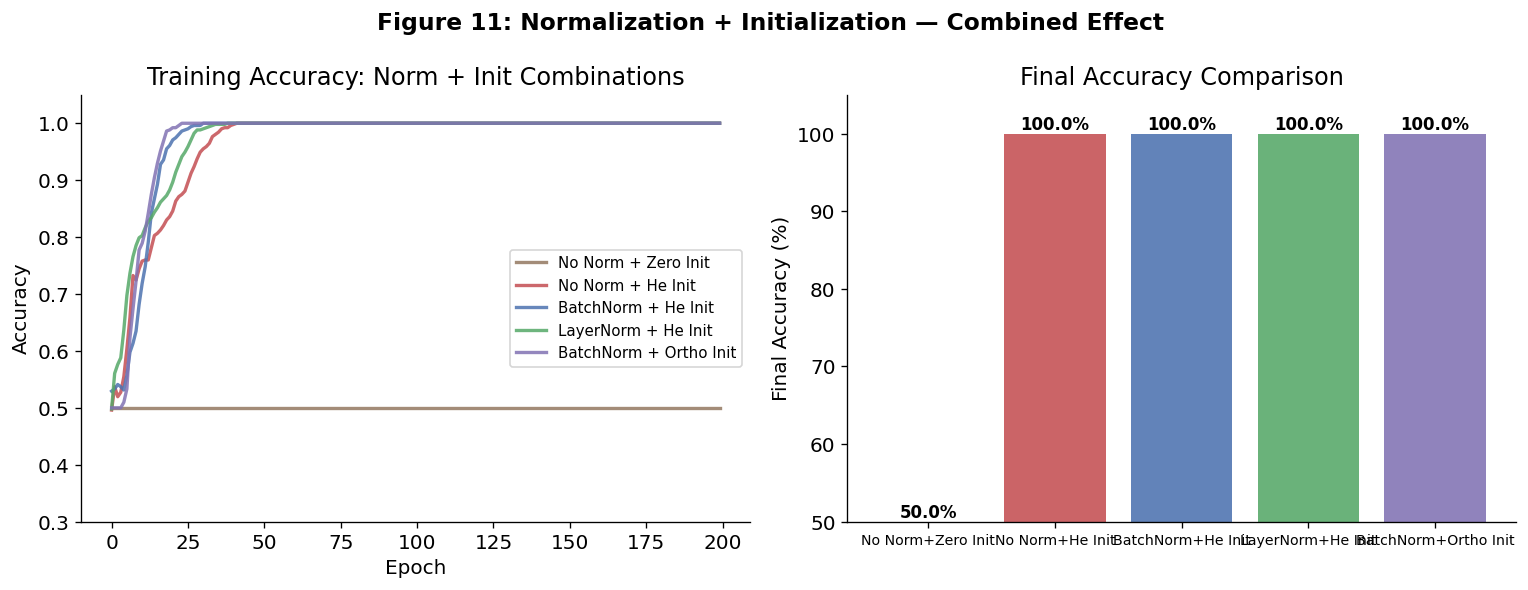

: 

In [ ]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt

torch.manual_seed(0)

# ── Dataset ──────────────────────────────────────────────────────
N = 512
X = torch.randn(N, 32)
y = (X[:, :16].sum(dim=1) > 0).long()   # simple linear classification

# ── Model factory ─────────────────────────────────────────────────
def make_model(norm_type, init_type, depth=8, width=64):
    layers = []
    n_in = 32
    for i in range(depth):
        lin = nn.Linear(n_in, width)
        # Initialization
        if init_type == 'zeros':
            nn.init.zeros_(lin.weight)
        elif init_type == 'xavier':
            nn.init.xavier_normal_(lin.weight)
        elif init_type == 'he':
            nn.init.kaiming_normal_(lin.weight, nonlinearity='relu')
        elif init_type == 'ortho':
            nn.init.orthogonal_(lin.weight)
        nn.init.zeros_(lin.bias)
        layers.append(lin)
        # Normalization
        if norm_type == 'bn':
            layers.append(nn.BatchNorm1d(width))
        elif norm_type == 'ln':
            layers.append(nn.LayerNorm(width))
        layers.append(nn.ReLU())
        n_in = width
    layers.append(nn.Linear(width, 2))
    return nn.Sequential(*layers)

def train_model(norm, init, epochs=200):
    model = make_model(norm, init)
    opt   = optim.Adam(model.parameters(), lr=1e-3)
    crit  = nn.CrossEntropyLoss()
    hist  = []
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        l = crit(model(X), y); l.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            acc = (model(X).argmax(1) == y).float().mean().item()
        hist.append(acc)
    return hist

configs = [
    ('none', 'zeros',  '#937860', 'No Norm + Zero Init'),
    ('none', 'he',     '#C44E52', 'No Norm + He Init'),
    ('bn',   'he',     '#4C72B0', 'BatchNorm + He Init'),
    ('ln',   'he',     '#55A868', 'LayerNorm + He Init'),
    ('bn',   'ortho',  '#8172B3', 'BatchNorm + Ortho Init'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

results = {}
for norm, init, col, label in configs:
    hist = train_model(norm, init)
    results[label] = hist
    axes[0].plot(hist, color=col, lw=2, label=label, alpha=0.85)
    print(f"{label:30s} | Final acc: {hist[-1]*100:.1f}%")

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training Accuracy: Norm + Init Combinations')
axes[0].legend(fontsize=9); axes[0].set_ylim(0.3, 1.05)

# ── Bar chart final accuracy ──
labels = list(results.keys())
accs   = [results[l][-1]*100 for l in labels]
colors_bar = [c for *_, c, __ in configs]

bars = axes[1].bar(range(len(labels)), accs, color=[c for _,_,c,__ in configs], alpha=0.88)
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels([l.replace(' + ', '+') for l in labels], fontsize=8.5)
axes[1].set_ylabel('Final Accuracy (%)'); axes[1].set_title('Final Accuracy Comparison')
axes[1].set_ylim(50, 105)
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{acc:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Figure 11: Normalization + Initialization — Combined Effect', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 14. Master Interview Q&A Cheatsheet

### Level 1 — Beginner

> **Q: What is Batch Normalization and what problem does it solve?**
> A: BatchNorm normalises layer inputs to have zero mean and unit variance within each mini-batch. It solves Internal Covariate Shift — the shifting distribution of layer inputs as weights update — allowing faster training with larger learning rates and less sensitivity to initialization.

> **Q: Where in a network is BatchNorm typically applied?**
> A: After the linear/conv layer and before the activation: `Linear → BatchNorm → ReLU`. Some modern architectures use pre-norm (norm before the sub-layer) instead.

> **Q: Why do we need learnable γ and β in BatchNorm?**
> A: Without them, the network is forced to operate in the zero-mean, unit-variance regime forever. γ and β let the network undo the normalisation if that's optimal — e.g., learn γ=σ, β=μ to restore the original distribution.

> **Q: Why do transformers use LayerNorm instead of BatchNorm?**
> A: LayerNorm works at batch size 1 (needed for auto-regressive generation), handles variable-length sequences, and behaves identically at train and test time. BatchNorm requires large batches and breaks for single-sample inference.

---

### Level 2 — Mid-Level

> **Q: What happens to BatchNorm at batch size 1?**
> A: Catastrophic failure — with one sample, variance=0, causing division by zero (or ε). The running statistics accumulated during training are used at eval time, but training with batch=1 is broken. Solutions: LayerNorm, GroupNorm, or use a batch size ≥ 8.

> **Q: Explain He initialization and why it works for ReLU.**
> A: ReLU zeroes all negative pre-activations, halving the effective variance of each layer's output. He initialization doubles the normal Xavier variance ($2/n_{in}$ vs $1/n_{in}$) to exactly compensate, maintaining signal variance across depth.

> **Q: What is the difference between nn.BatchNorm1d train mode and eval mode?**
> A: Train mode: normalises using the current mini-batch statistics and updates running mean/var. Eval mode: normalises using the accumulated running statistics (stable population estimates). Forgetting `model.eval()` causes inconsistent normalisation at inference.

> **Q: GroupNorm vs BatchNorm for object detection — which would you choose and why?**
> A: GroupNorm. Object detection models use high-resolution images requiring much larger memory, limiting batch sizes to 1-2 per GPU. BatchNorm with batch=2 has unstable statistics (high variance of mini-batch estimates). GroupNorm is independent of batch size — it normalises within channel groups per sample, giving stable statistics at any batch size.

---

### Level 3 — Senior MLE / Staff Engineer

> **Q: A very deep (50-layer) ReLU network is suffering from vanishing gradients despite using He init. What would you try?**
> A: (1) Add BatchNorm or LayerNorm after each linear layer — normalisation is the primary fix for gradient stability at depth. (2) Add residual connections (skip connections) — bypasses gradient through layers directly. (3) Check activations with hooks — are there dead ReLU neurons? Switch to Leaky ReLU or GELU. (4) Re-verify He init is applied correctly — mode='fan_in', nonlinearity='relu'. (5) Consider orthogonal init for the initial layers. (6) Use gradient checkpointing to verify gradient magnitudes per layer.

> **Q: Explain how Pre-LayerNorm differs from Post-LayerNorm in transformers and why it matters.**
> A: Post-LN (original Transformer): LayerNorm applied after residual addition. Pre-LN (GPT-2, modern): LayerNorm applied before sublayer. Pre-LN enables training without learning rate warmup for deep transformers — the residual path is always clean, gradients flow unobstructed. Post-LN requires careful warmup and can collapse with aggressive LR. Pre-LN is now the overwhelming standard for deep transformers.

> **Q: How would you initialise the output layer of a language model (next-token prediction) for fast convergence?**
> A: (1) Small init for the output projection (std=0.02 as in GPT-2) to prevent initial logits from being too spread. (2) Init the output embedding matrix the same as the input embedding (weight tying) — reduces parameters and provides a good starting point. (3) For the final linear layer, some practitioners init to zero and add a learnable scale — "zero init trick" for residual branches. (4) biases to log(class_freq) if classes are imbalanced — prevents early training from wasting steps correcting the bias.
